# Product Segmentation
### Unsupervised product segmentation with a supervised regression component for model validation

This notebook implements the project described in *Product_Segmentation_Project_Review.docx* on the dataset `Product_Segmentation_Dataset__ML.csv`.

**Pipeline:** data understanding → EDA → pre-processing → clustering (K-Means, Hierarchical, GMM, DBSCAN) → segment interpretation & business actions → supplementary Linear Regression → validation & generalization.

> **How the review was adapted to this dataset.** The review assumed raw *transaction-level* data (UCI Online Retail). The dataset provided is different: it is **already one row per product (600 products)** and has different columns. The pipeline was adapted as follows:
>
> | Review assumption | This dataset | How it is handled |
> |---|---|---|
> | Transaction lines (InvoiceNo, InvoiceDate, CustomerID, Country…) | One row per product, 10 columns | Invoice cleaning and product-level aggregation are **not needed**; replaced by data-quality checks |
> | 5 engineered features (Total Quantity, Avg Price, Total Revenue, Purchase Frequency, Unique Customers) | `Price`, `Units_Sold`, `Revenue`, `Rating`, `Reviews`, `Discount`, `Return_Rate` + `Category` | All 7 numeric columns are used for clustering. `Reviews` is the closest available proxy for purchase frequency / customer reach |
> | Regression: Revenue from the 4 other features | Revenue from `Price`, `Units_Sold`, `Rating`, `Reviews`, `Discount`, `Return_Rate` + `Category` | `Category` is one-hot encoded |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold, learning_curve
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, r2_score, mean_squared_error, mean_absolute_error)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

---
# 1. Problem Definition and Dataset Understanding

## 1.1 Problem definition
E-commerce platforms list thousands of products that differ widely in price, sales volume, customer engagement and revenue contribution. Treating them all alike makes inventory, pricing and marketing inefficient. This project uses **unsupervised learning to group products with similar sales and demand behaviour**, so every segment can be given a business meaning (e.g. *high-demand*, *premium*, *regular*, *low-performing*) and an action plan.

## 1.2 Objectives
1. Understand the dataset and check its quality.
2. Explore distributions, skew, outliers and correlations.
3. Scale features and apply K-Means, Hierarchical clustering, GMM (and DBSCAN for outliers).
4. Choose the number of clusters and evaluate quality with internal metrics.
5. Interpret each cluster and turn it into business recommendations.
6. Build a supplementary Linear Regression model (predict `Revenue`) to demonstrate train/test evaluation, cross-validation, over/under-fitting and the bias–variance trade-off.

## 1.3 Dataset description

In [2]:
DATA_PATH = "Product_Segmentation_Dataset__ML.csv"   # keep the CSV in the same folder as this notebook
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(8))
df.info()

Shape: (600, 10)


,Product_ID,Product_Name,Category,Price,Units_Sold,Revenue,Rating,Reviews,Discount,Return_Rate
0,P0001,Product_1,Grocery,"3,123.81",382,"945,089.97",4.60,69,20.80,8.49
1,P0002,Product_2,Beauty,"19,504.44",2624,"31,731,383.35",3.70,844,38.00,6.65
2,P0003,Product_3,Sports,"4,121.53",1736,"4,972,708.38",4.30,924,30.50,3.53
3,P0004,Product_4,Grocery,"6,172.08",1213,"4,132,676.64",4.50,760,44.80,5.74
4,P0005,Product_5,Fashion,"2,535.22",375,"561,868.13",4.40,185,40.90,4.87
5,P0006,Product_6,Sports,"3,129.78",210,"574,439.82",4.40,50,12.60,5.30
6,P0007,Product_7,Sports,"5,002.69",2489,"10,758,264.83",4.00,1240,13.60,7.87
7,P0008,Product_8,Grocery,"3,297.35",719,"2,221,434.59",3.60,189,6.30,0.50


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    600 non-null    str    
 1   Product_Name  600 non-null    str    
 2   Category      600 non-null    str    
 3   Price         600 non-null    float64
 4   Units_Sold    600 non-null    int64  
 5   Revenue       600 non-null    float64
 6   Rating        600 non-null    float64
 7   Reviews       600 non-null    int64  
 8   Discount      600 non-null    float64
 9   Return_Rate   600 non-null    float64
dtypes: float64(5), int64(2), str(3)
memory usage: 47.0 KB


| Column | Type | Meaning |
|---|---|---|
| `Product_ID`, `Product_Name` | identifier | Product key and name (labels only, **not** model inputs) |
| `Category` | categorical | Product category (7 levels) |
| `Price` | numeric | Selling price per unit |
| `Units_Sold` | numeric | Total units sold |
| `Revenue` | numeric | Total revenue from the product |
| `Rating` | numeric | Average customer rating (1–5) |
| `Reviews` | numeric | Number of customer reviews |
| `Discount` | numeric | Average discount (%) |
| `Return_Rate` | numeric | Share of units returned (%) |

---
# 2. Exploratory Data Analysis

## 2.1 Data exploration – quality checks

In [3]:
NUMERIC = ["Price", "Units_Sold", "Revenue", "Rating", "Reviews", "Discount", "Return_Rate"]

quality = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isnull().sum(), "unique values": df.nunique()})
display(quality)
print("Duplicate rows:", df.duplicated().sum(), "| Duplicate Product_IDs:", df["Product_ID"].duplicated().sum())
print("Unique products:", df["Product_ID"].nunique(), "| Categories:", df["Category"].nunique())

# Invalid-record checks (the dataset-appropriate version of the review's "non-positive Quantity/Price" rule)
violations = pd.Series({
    "Price <= 0": (df.Price <= 0).sum(),
    "Units_Sold <= 0": (df.Units_Sold <= 0).sum(),
    "Revenue <= 0": (df.Revenue <= 0).sum(),
    "Reviews < 0": (df.Reviews < 0).sum(),
    "Rating outside 1-5": (~df.Rating.between(1, 5)).sum(),
    "Discount outside 0-100 %": (~df.Discount.between(0, 100)).sum(),
    "Return_Rate outside 0-100 %": (~df.Return_Rate.between(0, 100)).sum(),
}, name="invalid rows")
display(violations)

,dtype,missing,unique values
Product_ID,str,0,600
Product_Name,str,0,600
Category,str,0,7
Price,float64,0,600
Units_Sold,int64,0,538
Revenue,float64,0,600
Rating,float64,0,23
Reviews,int64,0,482
Discount,float64,0,345
Return_Rate,float64,0,411


Duplicate rows: 0 | Duplicate Product_IDs: 0
Unique products: 600 | Categories: 7


,invalid rows
Price <= 0,0
Units_Sold <= 0,0
Revenue <= 0,0
Reviews < 0,0
Rating outside 1-5,0
Discount outside 0-100 %,0
Return_Rate outside 0-100 %,0


In [4]:
# Is Revenue an independent measurement, or derived from other columns?
net_sales = df.Price * df.Units_Sold * (1 - df.Discount / 100)
rel_diff = (df.Revenue / net_sales - 1).abs()
print(f"Max relative difference between Revenue and Price x Units_Sold x (1 - Discount/100): {rel_diff.max():.1e}")
print(f"Products where they differ by more than 0.01 %: {(rel_diff > 1e-4).sum()}")
ratio = df.Revenue / (df.Price * df.Units_Sold)
print(f"Revenue / (Price x Units_Sold) ranges from {ratio.min():.2f} to {ratio.max():.2f}")

Max relative difference between Revenue and Price x Units_Sold x (1 - Discount/100): 2.3e-07
Products where they differ by more than 0.01 %: 0
Revenue / (Price x Units_Sold) ranges from 0.50 to 1.00


**Key finding - `Revenue` is a derived column.** It equals `Price × Units_Sold × (1 − Discount/100)` for every product (to within rounding error). It is therefore *not* an independent measurement, and this has two consequences that are handled explicitly later:

1. **Clustering (Section 4.2):** `Revenue` is redundant with `Price`, `Units_Sold` and `Discount`, so it gives those three columns extra weight. It is kept because the review lists it as a core feature, and a robustness check (Section 4.2, Step 5) shows how much the segmentation changes without it.
2. **Regression (Sections 4.4 and 5):** predicting `Revenue` is partly a *formula-recovery* task. A plain linear model cannot represent a product of variables (so it will under-fit), while a flexible model can reproduce the formula exactly (so it cannot be used to demonstrate over-fitting). Section 5 deals with this by using `Revenue` to show under-fitting and a second, genuinely noisy target (`Units_Sold`) to show over-fitting and variance.

## 2.2 Statistical analysis

In [5]:
stats = df[NUMERIC].describe().T
stats["skew"] = df[NUMERIC].skew()
display(stats)

rev_sorted = df.Revenue.sort_values(ascending=False)
top20 = rev_sorted.head(int(0.2 * len(df))).sum() / rev_sorted.sum()
top10 = rev_sorted.head(int(0.1 * len(df))).sum() / rev_sorted.sum()
print(f"Top 10% of products generate {top10:.1%} of revenue; top 20% generate {top20:.1%} (Pareto-style concentration).")

,count,mean,std,min,25%,50%,75%,max,skew
Price,600.00,"4,111.32","3,758.05",200.00,"1,750.72","2,996.35","5,318.69","27,640.07",2.53
Units_Sold,600.00,"1,505.74",859.56,21.00,774.00,"1,423.50","2,220.00","2,999.00",0.05
Revenue,600.00,"4,688,350.62","5,860,428.11","20,428.09","1,238,019.68","2,875,162.67","5,988,521.13","48,295,981.58",3.61
Rating,600.00,4.09,0.43,2.60,3.80,4.10,4.40,5.00,-0.21
Reviews,600.00,614.40,481.15,5.00,214.75,492.00,913.50,"2,031.00",0.86
Discount,600.00,25.83,14.00,0.10,14.80,26.20,37.70,50.00,-0.13
Return_Rate,600.00,5.81,2.03,0.50,4.33,5.73,7.26,11.66,0.05


Top 10% of products generate 38.4% of revenue; top 20% generate 57.0% (Pareto-style concentration).


`Price` (skew ≈ 2.5) and `Revenue` (skew ≈ 3.6) are strongly right-skewed: a small group of expensive / high-revenue products sits far from the bulk. `Units_Sold`, `Discount`, `Return_Rate` and `Rating` are roughly symmetric. This skew motivates **scaling** before the distance-based clustering in Section 3.3.

## 2.3 Data visualization

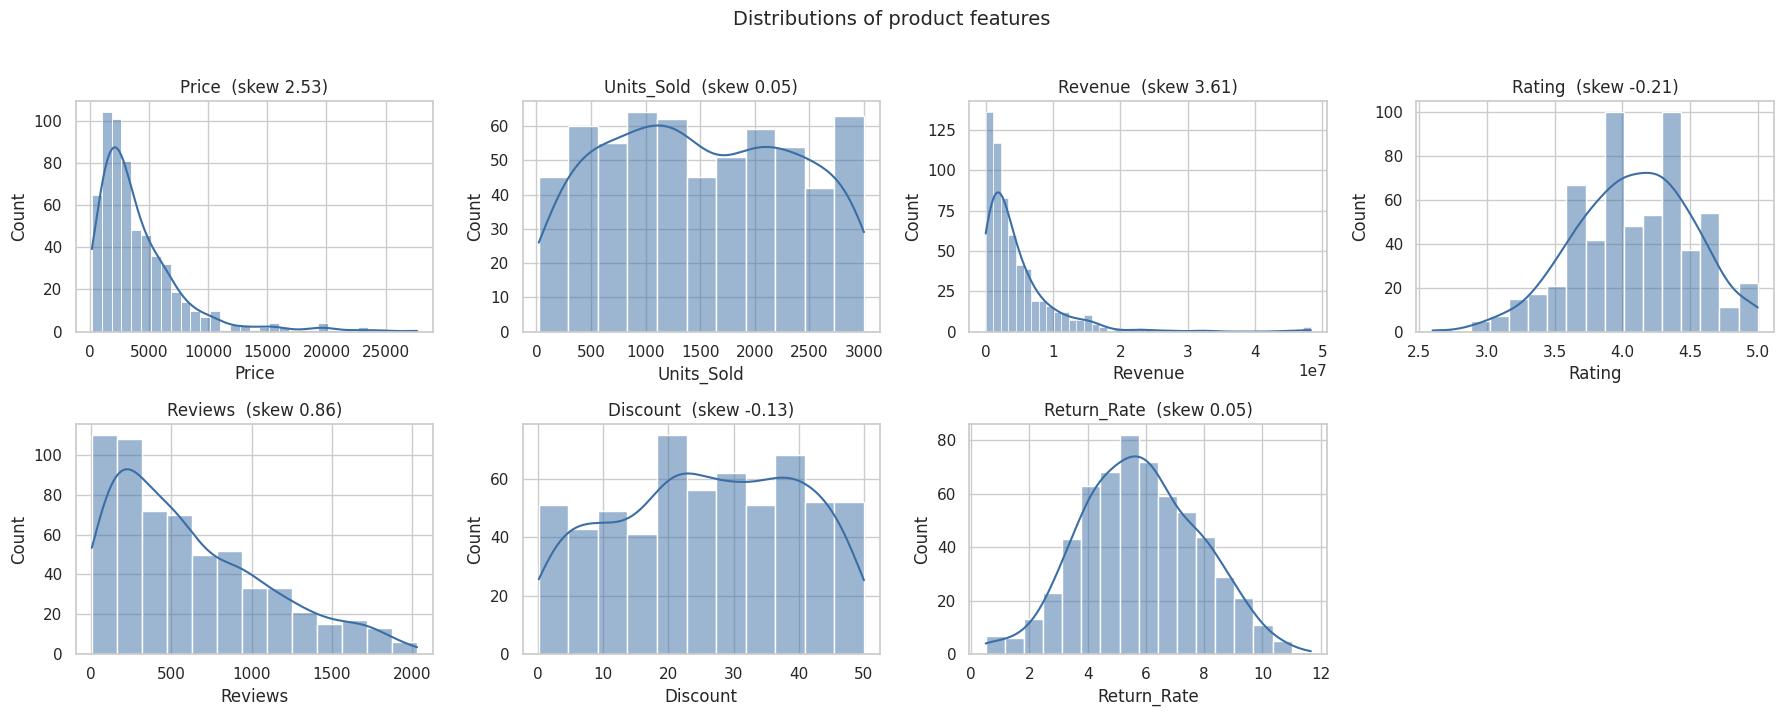

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), NUMERIC):
    sns.histplot(df[col], kde=True, ax=ax, color="#3b6ea5")
    ax.set_title(f"{col}  (skew {df[col].skew():.2f})")
axes.ravel()[-1].axis("off")
fig.suptitle("Distributions of product features", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

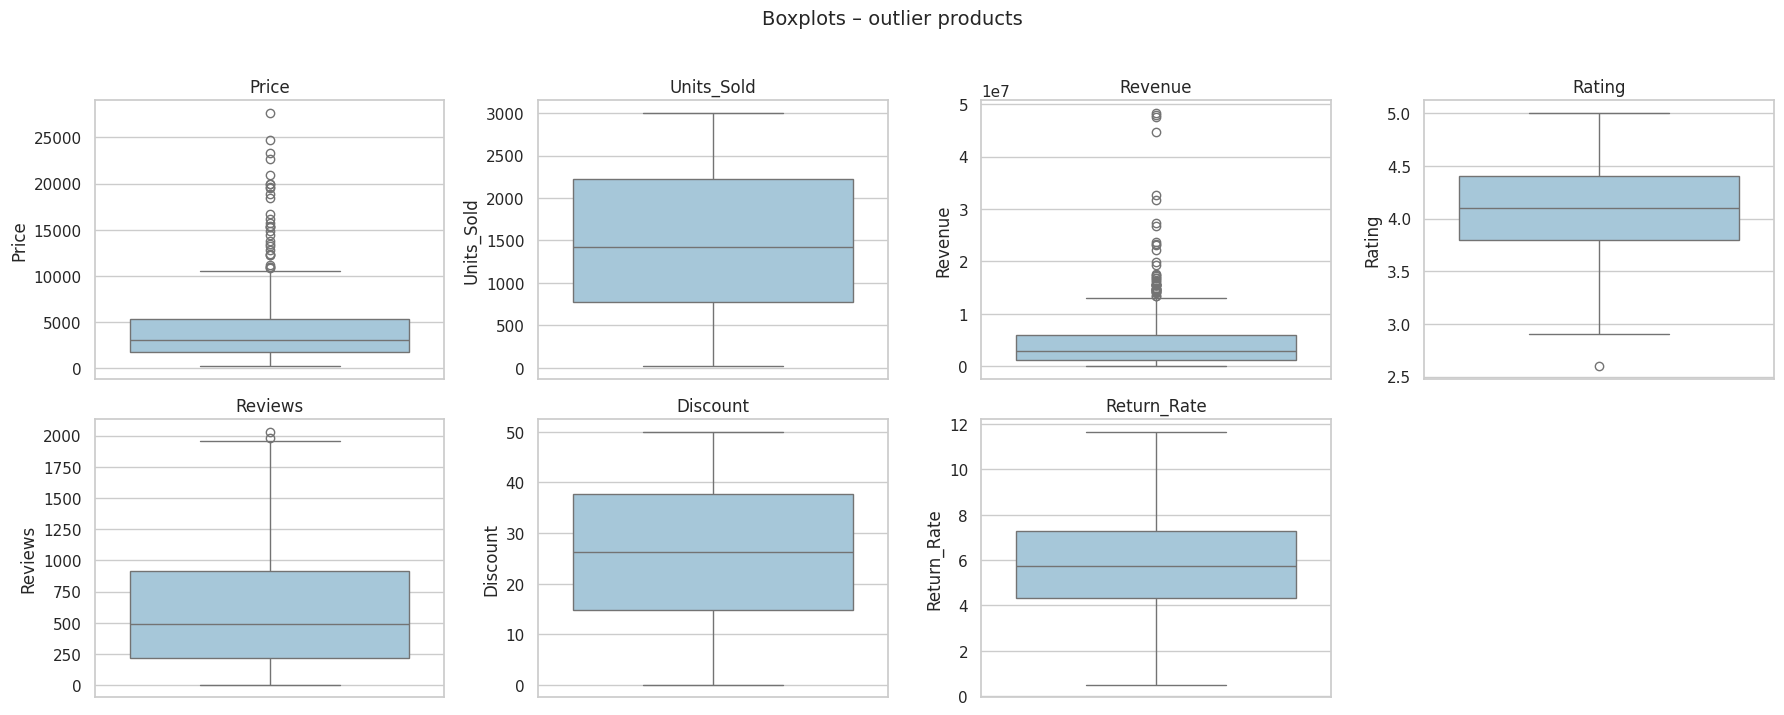

,outlier count (IQR rule),% of products
Price,30,5.00
Units_Sold,0,0.00
Revenue,41,6.83
Rating,1,0.17
Reviews,2,0.33
Discount,0,0.00
Return_Rate,0,0.00


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), NUMERIC):
    sns.boxplot(y=df[col], ax=ax, color="#9ecae1")
    ax.set_title(col)
axes.ravel()[-1].axis("off")
fig.suptitle("Boxplots – outlier products", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

q1, q3 = df[NUMERIC].quantile(.25), df[NUMERIC].quantile(.75)
iqr = q3 - q1
outliers = ((df[NUMERIC] < q1 - 1.5 * iqr) | (df[NUMERIC] > q3 + 1.5 * iqr)).sum()
display(pd.DataFrame({"outlier count (IQR rule)": outliers, "% of products": outliers / len(df) * 100}))

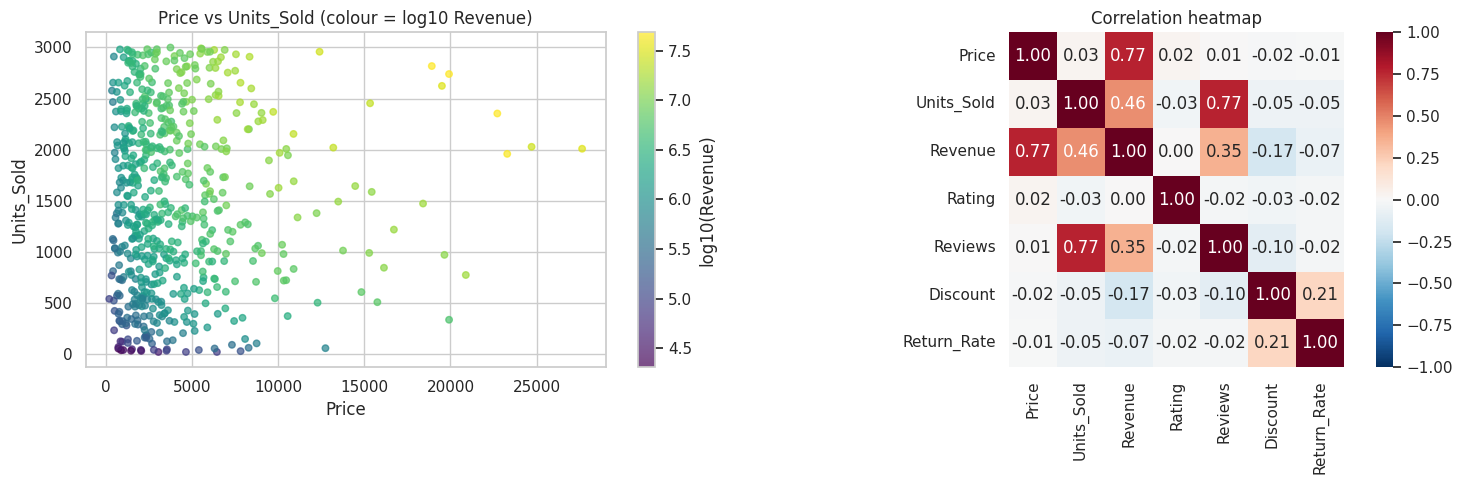

corr(Price, Units_Sold) = 0.03  -> no inverse price-volume relationship in this data
corr(Units_Sold, Reviews) = 0.77  -> Reviews and Units_Sold carry overlapping information


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sc = axes[0].scatter(df.Price, df.Units_Sold, c=np.log10(df.Revenue), cmap="viridis", alpha=.7, s=22)
axes[0].set_xlabel("Price"); axes[0].set_ylabel("Units_Sold"); axes[0].set_title("Price vs Units_Sold (colour = log10 Revenue)")
plt.colorbar(sc, ax=axes[0], label="log10(Revenue)")
corr = df[NUMERIC].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[1], square=True)
axes[1].set_title("Correlation heatmap")
plt.tight_layout(); plt.show()
print(f"corr(Price, Units_Sold) = {corr.loc['Price','Units_Sold']:.2f}  -> no inverse price-volume relationship in this data")
print(f"corr(Units_Sold, Reviews) = {corr.loc['Units_Sold','Reviews']:.2f}  -> Reviews and Units_Sold carry overlapping information")

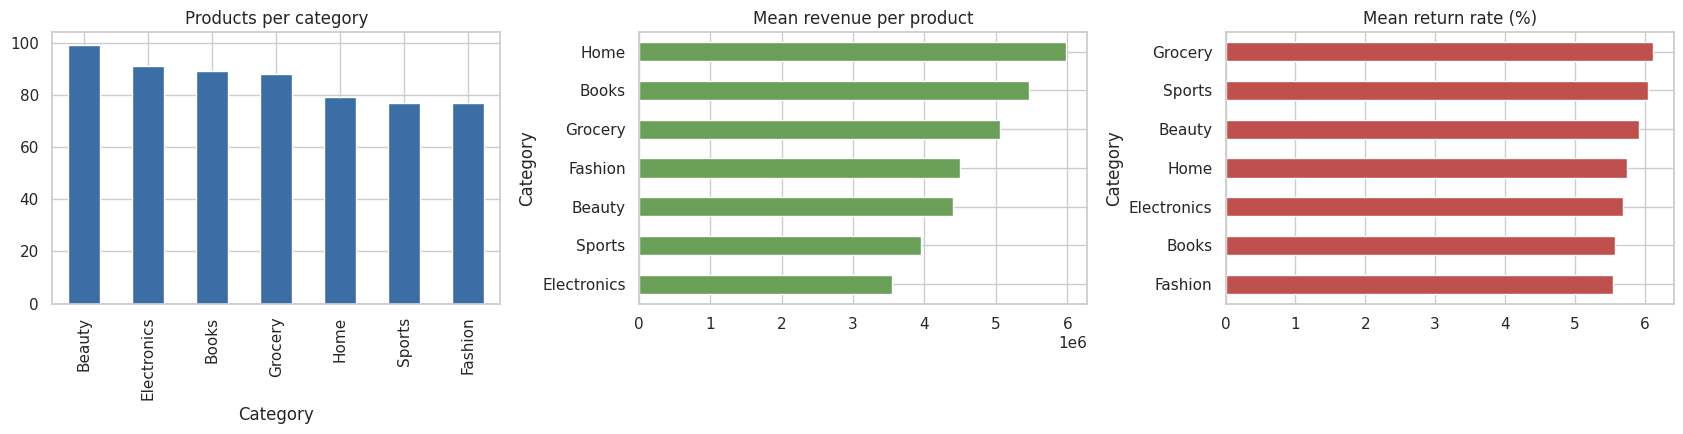

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
df.Category.value_counts().plot.bar(ax=axes[0], color="#3b6ea5"); axes[0].set_title("Products per category")
df.groupby("Category").Revenue.mean().sort_values().plot.barh(ax=axes[1], color="#6a9f58"); axes[1].set_title("Mean revenue per product")
df.groupby("Category").Return_Rate.mean().sort_values().plot.barh(ax=axes[2], color="#c0504d"); axes[2].set_title("Mean return rate (%)")
plt.tight_layout(); plt.show()

**EDA takeaways**
- `Revenue` is strongly correlated with `Price` (r ≈ 0.77) and moderately with `Units_Sold` (r ≈ 0.46) - it is derived from them (and `Discount`). `Reviews` tracks `Units_Sold` closely (r ≈ 0.77).
- `Rating`, `Discount` and `Return_Rate` are only weakly correlated with the other features (|r| ≤ 0.21), so they add largely *independent* dimensions to the segmentation (e.g. separating products that sell similar volumes but with very different discount/return behaviour).
- Categories are fairly balanced in size (77–99 products each) with only modest differences in average revenue and return rate – category will be used to *describe* segments rather than to build them.

---
# 3. Data Pre-processing

## 3.1 Missing-value and invalid-record treatment
The review's transaction cleaning (guest orders, cancelled invoices, missing descriptions) is not applicable because the data is already aggregated and complete. The code below *asserts* that, so the notebook fails loudly if a different file is ever used.

In [10]:
assert df[NUMERIC + ["Category", "Product_ID"]].isnull().sum().sum() == 0, "missing values found"
assert df.duplicated().sum() == 0 and violations.sum() == 0, "duplicates / invalid rows found"
print("No missing values, duplicates or invalid rows -> no rows removed. Products kept:", len(df))

No missing values, duplicates or invalid rows -> no rows removed. Products kept: 600


**Outliers are kept.** The IQR rule flags a block of high-`Price` / high-`Revenue` products (about 5–7 % of products). These are not errors – they are the *premium* products the segmentation should isolate – so removing them would defeat the purpose.

## 3.2 Categorical data encoding
- **Clustering:** uses the 7 numeric features only. `Product_ID`, `Product_Name` and `Category` are identifiers / profiling labels, not inputs.
- **Regression (Section 4.4):** `Category` is one-hot encoded (`drop_first=True` to avoid the dummy-variable trap).

## 3.3 Feature scaling
`Revenue` (millions) and `Price` (thousands) are on far larger numeric scales than `Rating` (1–5) or `Return_Rate` (%). Unscaled, they would dominate every distance calculation. `StandardScaler` gives each feature mean 0 and standard deviation 1:

*Product features → StandardScaler → Scaled features → Clustering algorithm*

In [11]:
CLUSTER_FEATURES = NUMERIC
scaler = StandardScaler()
Z = scaler.fit_transform(df[CLUSTER_FEATURES])
display(pd.DataFrame(Z, columns=CLUSTER_FEATURES).describe().loc[["mean", "std"]].round(3))

,Price,Units_Sold,Revenue,Rating,Reviews,Discount,Return_Rate
mean,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00


> **Note on scaler fitting.** Clustering has no train/test split, so its scaler is fitted on all 600 products. The regression model in Section 4.4 uses a *separate* scaler fitted **on the training rows only** (inside a pipeline); re-using the clustering scaler there would leak test-set statistics into training.

---
# 4. Model Development

## 4.1 Training and testing data
Clustering is unsupervised (no ground-truth labels), so it is fitted on the **full scaled product dataset**. A train/test split is used only for the supplementary regression model (Section 4.4).

## 4.2 Core model – product segmentation via clustering

### Step 1 – Choosing the number of clusters (K)
K-Means is run for K = 2…10. The **Elbow method** (WCSS), **Silhouette** (higher is better), **Davies-Bouldin** (lower is better) and **Calinski-Harabasz** (higher is better) are compared. GMM (BIC) and Ward hierarchical clustering (silhouette) are used as cross-checks.

,WCSS,Silhouette,Davies_Bouldin,Calinski_Harabasz,Smallest_cluster
K,,,,,
2,"3,318.54",0.22,1.80,158.85,233
3,"2,825.70",0.21,1.56,145.18,44
4,"2,516.82",0.17,1.63,132.86,44
5,"2,303.42",0.16,1.60,122.48,35
6,"2,131.85",0.17,1.46,115.25,9
7,"1,990.22",0.16,1.48,109.74,8
8,"1,871.47",0.16,1.49,105.23,9
9,"1,786.26",0.16,1.47,99.83,8
10,"1,689.10",0.16,1.49,97.45,7


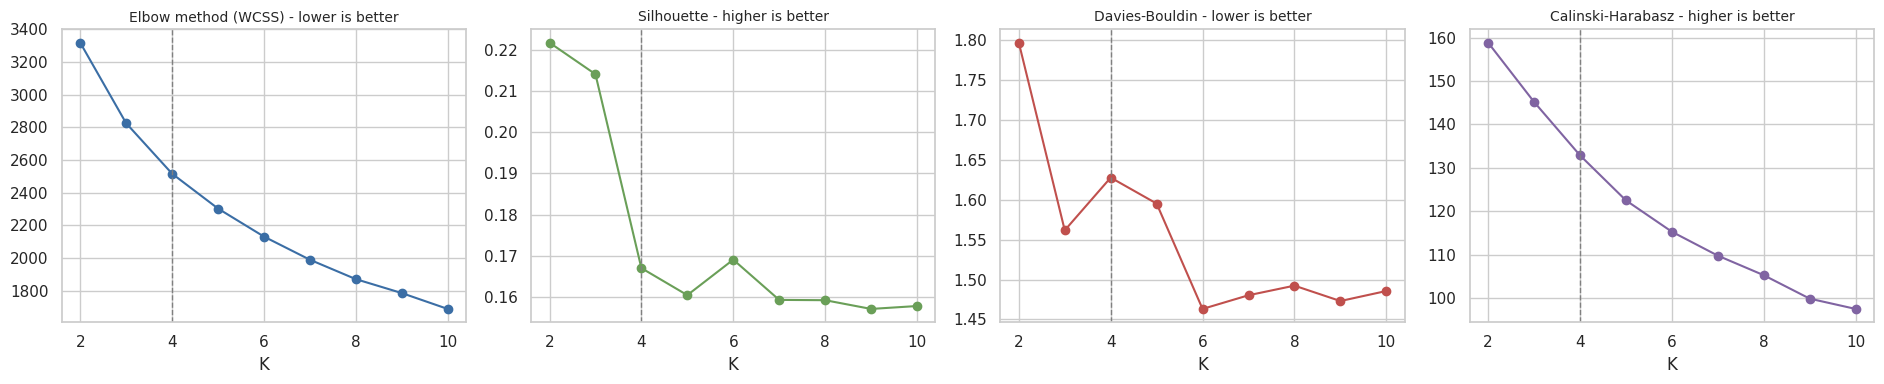

In [12]:
K_RANGE = range(2, 11)
rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Z)
    rows.append({"K": k, "WCSS": km.inertia_,
                 "Silhouette": silhouette_score(Z, km.labels_),
                 "Davies_Bouldin": davies_bouldin_score(Z, km.labels_),
                 "Calinski_Harabasz": calinski_harabasz_score(Z, km.labels_),
                 "Smallest_cluster": int(np.bincount(km.labels_).min())})
k_table = pd.DataFrame(rows).set_index("K")
display(k_table)

fig, axes = plt.subplots(1, 4, figsize=(19, 4))
spec = [("WCSS", "Elbow method (WCSS) - lower is better", "#3b6ea5"),
        ("Silhouette", "Silhouette - higher is better", "#6a9f58"),
        ("Davies_Bouldin", "Davies-Bouldin - lower is better", "#c0504d"),
        ("Calinski_Harabasz", "Calinski-Harabasz - higher is better", "#8064a2")]
for ax, (col, title, c) in zip(axes, spec):
    ax.plot(k_table.index, k_table[col], marker="o", color=c)
    ax.axvline(4, ls="--", color="grey", lw=1); ax.set_title(title, fontsize=10); ax.set_xlabel("K")
plt.tight_layout(); plt.show()

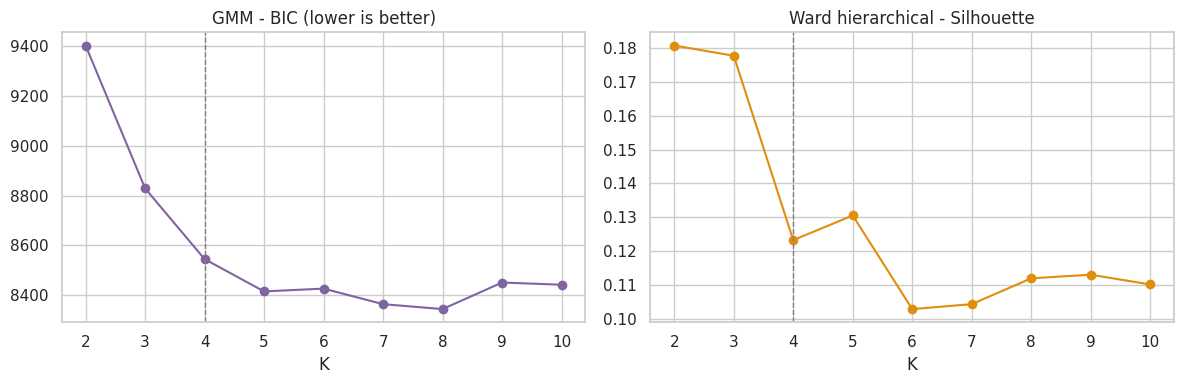

GMM BIC by K: {2: 9403, 3: 8829, 4: 8544, 5: 8414, 6: 8426, 7: 8363, 8: 8344, 9: 8450, 10: 8441}


In [13]:
gmm_bic = [GaussianMixture(k, covariance_type="full", n_init=3, random_state=RANDOM_STATE).fit(Z).bic(Z) for k in K_RANGE]
hier_sil = [silhouette_score(Z, AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(Z)) for k in K_RANGE]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), gmm_bic, marker="o", color="#8064a2"); axes[0].set_title("GMM - BIC (lower is better)"); axes[0].set_xlabel("K")
axes[1].plot(list(K_RANGE), hier_sil, marker="o", color="#e08e0b"); axes[1].set_title("Ward hierarchical - Silhouette"); axes[1].set_xlabel("K")
for a in axes: a.axvline(4, ls="--", color="grey", lw=1)
plt.tight_layout(); plt.show()
print("GMM BIC by K:", {k: int(round(v)) for k, v in zip(K_RANGE, gmm_bic)})

In [14]:
best_sil_k = int(k_table.Silhouette.idxmax())
display(Markdown(f"""
**Reading the metrics honestly.**
- Silhouette is highest at **K = {best_sil_k}** ({k_table.Silhouette.max():.3f}), nearly as high at K = 3 ({k_table.loc[3,'Silhouette']:.3f}), **{k_table.loc[4,'Silhouette']:.3f}** at K = 4, and then flat at about 0.16. Every value is below 0.25, i.e. the products form **overlapping, continuous groups rather than sharply separated clusters**, and the elbow is gentle - there is no single obvious K.
- Davies-Bouldin is about 1.5-1.6 for K = 3-10. It is lowest at K = 6 ({k_table.loc[6,'Davies_Bouldin']:.2f}), but K = 6 already produces a cluster of only {k_table.loc[6,'Smallest_cluster']} products. Calinski-Harabasz simply falls as K grows, as it usually does.
- GMM's BIC drops steeply up to K = 5 ({gmm_bic[3]:,.0f} at K = 5 vs {gmm_bic[0]:,.0f} at K = 2) and then flattens. Ward hierarchical silhouette falls from {hier_sil[0]:.2f} (K = 2) to {hier_sil[2]:.2f} (K = 4).

**Decision: K = 4.** The metrics do not single out one K, so the review's rule - *balance the scores against interpretability* - decides.
K = 2 or 3 would merge the low-volume / high-discount / high-return products with the healthy mid-volume ones, hiding the most actionable difference. K = 4 gives four distinct business profiles (Section 4.3) and no tiny cluster (smallest = {k_table.loc[4,'Smallest_cluster']} products), whereas K >= 6 creates clusters of fewer than 10 products. The price paid is a lower silhouette than K = 2-3 and lower stability (Section 5.1) - this trade-off is stated openly rather than hidden.
"""))


**Reading the metrics honestly.**
- Silhouette is highest at **K = 2** (0.222), nearly as high at K = 3 (0.214), **0.167** at K = 4, and then flat at about 0.16. Every value is below 0.25, i.e. the products form **overlapping, continuous groups rather than sharply separated clusters**, and the elbow is gentle - there is no single obvious K.
- Davies-Bouldin is about 1.5-1.6 for K = 3-10. It is lowest at K = 6 (1.46), but K = 6 already produces a cluster of only 9 products. Calinski-Harabasz simply falls as K grows, as it usually does.
- GMM's BIC drops steeply up to K = 5 (8,414 at K = 5 vs 9,403 at K = 2) and then flattens. Ward hierarchical silhouette falls from 0.18 (K = 2) to 0.12 (K = 4).

**Decision: K = 4.** The metrics do not single out one K, so the review's rule - *balance the scores against interpretability* - decides.
K = 2 or 3 would merge the low-volume / high-discount / high-return products with the healthy mid-volume ones, hiding the most actionable difference. K = 4 gives four distinct business profiles (Section 4.3) and no tiny cluster (smallest = 44 products), whereas K >= 6 creates clusters of fewer than 10 products. The price paid is a lower silhouette than K = 2-3 and lower stability (Section 5.1) - this trade-off is stated openly rather than hidden.


### Step 2 – Fit the clustering algorithms (K = 4)

In [15]:
K_FINAL = 4

# --- K-Means (main algorithm)
kmeans = KMeans(n_clusters=K_FINAL, n_init=20, random_state=RANDOM_STATE).fit(Z)
df["KMeans"] = kmeans.labels_

# --- Hierarchical (Ward linkage)
Zl = linkage(Z, method="ward")
df["Hierarchical"] = fcluster(Zl, K_FINAL, criterion="maxclust") - 1

# --- Gaussian Mixture Model (soft membership)
gmm = GaussianMixture(K_FINAL, covariance_type="full", n_init=5, random_state=RANDOM_STATE).fit(Z)
df["GMM"] = gmm.predict(Z)
gmm_prob = gmm.predict_proba(Z)

print("Cluster sizes")
display(df[["KMeans", "Hierarchical", "GMM"]].apply(lambda s: s.value_counts().sort_index()).T)
print(f"GMM: mean max membership probability = {gmm_prob.max(1).mean():.2f}; "
      f"{(gmm_prob.max(1) < 0.7).mean():.1%} of products are 'ambiguous' (top probability < 0.7)")

Cluster sizes


,0,1,2,3
KMeans,200,44,165,191
Hierarchical,85,248,198,69
GMM,97,198,133,172


GMM: mean max membership probability = 0.96; 3.8% of products are 'ambiguous' (top probability < 0.7)


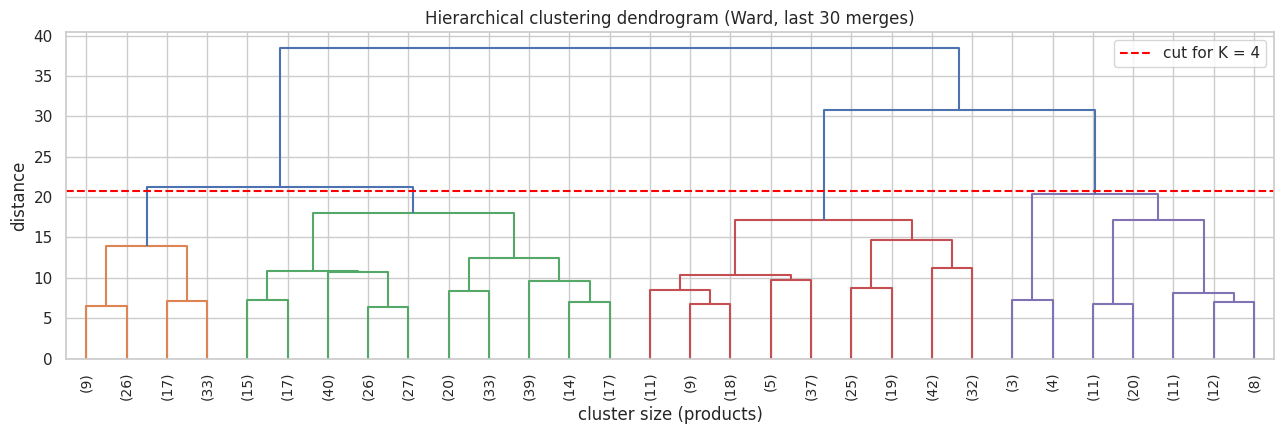

In [16]:
cut_height = (Zl[-(K_FINAL - 1), 2] + Zl[-K_FINAL, 2]) / 2
plt.figure(figsize=(13, 4.5))
dendrogram(Zl, truncate_mode="lastp", p=30, show_leaf_counts=True, leaf_rotation=90, color_threshold=cut_height, no_labels=False)
plt.axhline(cut_height, ls="--", color="red", label=f"cut for K = {K_FINAL}")
plt.title("Hierarchical clustering dendrogram (Ward, last 30 merges)"); plt.xlabel("cluster size (products)"); plt.ylabel("distance")
plt.legend(); plt.tight_layout(); plt.show()

### Step 3 – DBSCAN (optional): flag unusual products
DBSCAN does not need K; points that do not belong to any dense region are labelled noise (`-1`). It is used here to find **outlier products**, as the review suggests.

,eps,clusters,noise_products,noise_%
0,1.50,1,77,12.83
1,1.75,1,31,5.17
2,2.00,1,19,3.17
3,2.25,1,11,1.83
4,2.50,1,9,1.50
5,2.75,1,8,1.33
6,3.00,1,7,1.17
7,3.25,1,7,1.17
8,3.50,1,6,1.00


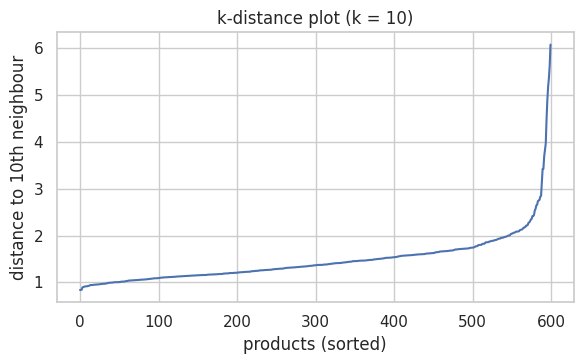

In [17]:
MIN_SAMPLES = 10
kdist = np.sort(NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z).kneighbors(Z)[0][:, -1])
grid = []
for eps in np.arange(1.5, 3.55, 0.25):
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Z)
    grid.append({"eps": round(eps, 2), "clusters": len(set(lab) - {-1}), "noise_products": int((lab == -1).sum()),
                 "noise_%": (lab == -1).mean() * 100})
grid = pd.DataFrame(grid)
display(grid)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(kdist); ax.set_title(f"k-distance plot (k = {MIN_SAMPLES})"); ax.set_xlabel("products (sorted)"); ax.set_ylabel("distance to 10th neighbour")
plt.tight_layout(); plt.show()

In [18]:
# choose the eps whose noise share is closest to ~5 % while still finding at least one cluster
cand = grid[grid.clusters >= 1]
EPS = float(cand.iloc[(cand["noise_%"] - 5).abs().argmin()]["eps"])
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(Z)
df["DBSCAN"] = db.labels_
df["Outlier_DBSCAN"] = db.labels_ == -1
print(f"DBSCAN eps = {EPS}: {len(set(db.labels_) - {-1})} dense cluster(s), {df.Outlier_DBSCAN.sum()} noise products ({df.Outlier_DBSCAN.mean():.1%})")

cmp = df.groupby("Outlier_DBSCAN")[CLUSTER_FEATURES].mean().rename(index={False: "regular products", True: "DBSCAN outliers"})
display(cmp)
print(f"DBSCAN outliers have a mean Price of {cmp.loc['DBSCAN outliers','Price']:,.0f} vs {cmp.loc['regular products','Price']:,.0f} for the rest: they are mainly very expensive products. "
      f"With these settings DBSCAN finds one dense cluster, so it is useful for outlier flagging only, not for segmentation.")

DBSCAN eps = 1.75: 1 dense cluster(s), 31 noise products (5.2%)


,Price,Units_Sold,Revenue,Rating,Reviews,Discount,Return_Rate
Outlier_DBSCAN,,,,,,,
regular products,"3,531.56","1,491.75","3,896,463.10",4.09,610.56,26.10,5.87
DBSCAN outliers,"14,752.87","1,762.42","19,223,318.47",3.99,685.00,20.78,4.66


DBSCAN outliers have a mean Price of 14,753 vs 3,532 for the rest: they are mainly very expensive products. With these settings DBSCAN finds one dense cluster, so it is useful for outlier flagging only, not for segmentation.


### Step 4 – Compare the algorithms

,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI_vs_KMeans,Smallest,Largest
Algorithm,,,,,,,
K-Means,4,0.17,1.63,132.86,1.00,44,200
Hierarchical (Ward),4,0.12,1.77,103.35,0.41,69,248
GMM,4,0.07,2.42,93.30,0.29,97,198
"DBSCAN (eps=1.75, noise excluded)",1,NaN,NaN,NaN,NaN,569,569


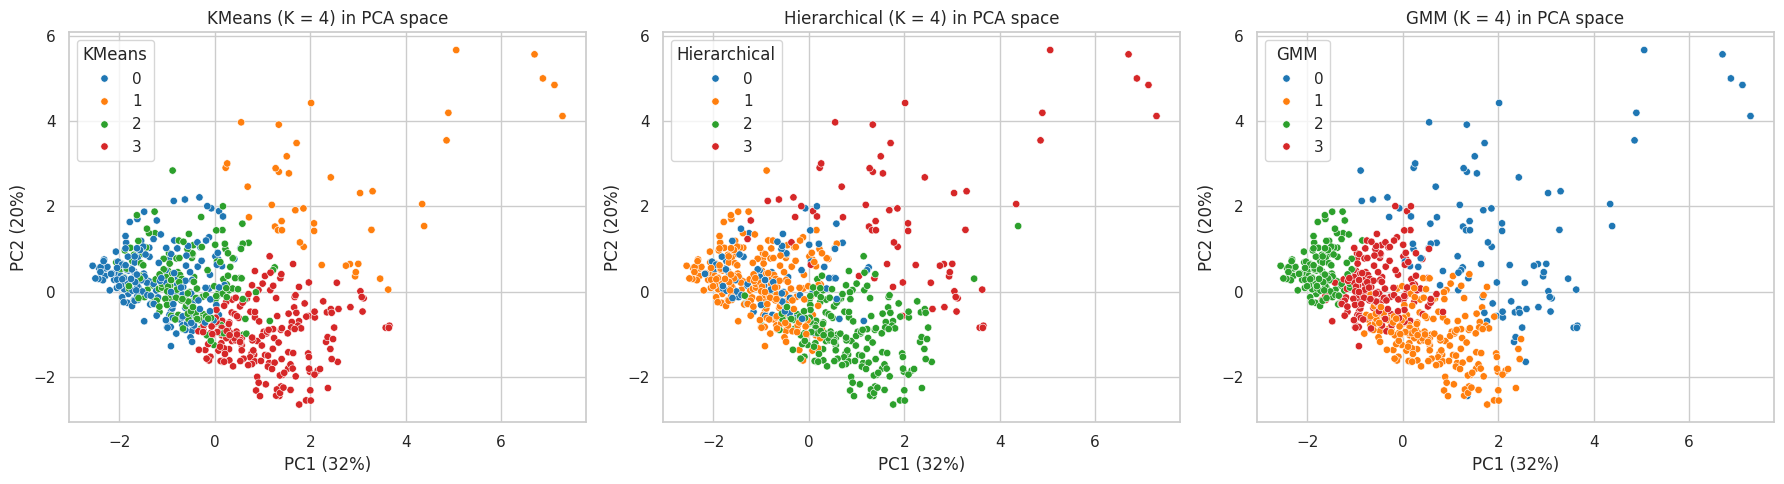

In [19]:
def internal_scores(labels, name):
    mask = labels != -1
    ok = len(set(labels[mask])) >= 2
    return {"Algorithm": name,
            "Clusters": len(set(labels[mask])),
            "Silhouette": silhouette_score(Z[mask], labels[mask]) if ok else np.nan,
            "Davies_Bouldin": davies_bouldin_score(Z[mask], labels[mask]) if ok else np.nan,
            "Calinski_Harabasz": calinski_harabasz_score(Z[mask], labels[mask]) if ok else np.nan,
            "ARI_vs_KMeans": adjusted_rand_score(df.KMeans[mask], labels[mask]) if ok else np.nan,
            "Smallest": int(np.bincount(labels[mask]).min()), "Largest": int(np.bincount(labels[mask]).max())}

comparison = pd.DataFrame([internal_scores(df.KMeans.values, "K-Means"),
                           internal_scores(df.Hierarchical.values, "Hierarchical (Ward)"),
                           internal_scores(df.GMM.values, "GMM"),
                           internal_scores(df.DBSCAN.values, f"DBSCAN (eps={EPS}, noise excluded)")]).set_index("Algorithm")
display(comparison)

pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Z)
P = pca.transform(Z)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["KMeans", "Hierarchical", "GMM"]):
    sns.scatterplot(x=P[:, 0], y=P[:, 1], hue=df[col], palette="tab10", s=28, ax=ax, legend="full")
    ax.set_title(f"{col} (K = {K_FINAL}) in PCA space"); ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})"); ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
plt.tight_layout(); plt.show()

In [20]:
def best_match_share(a, b):
    ct = pd.crosstab(a, b)
    return ct.max(axis=1) / ct.sum(axis=1) * 100
match = pd.DataFrame({"products": df.KMeans.value_counts().sort_index(),
                      "% of cluster inside ONE Hierarchical cluster": best_match_share(df.KMeans, df.Hierarchical),
                      "% of cluster inside ONE GMM cluster": best_match_share(df.KMeans, df.GMM)})
match.index.name = "K-Means cluster"
display(match)

,products,% of cluster inside ONE Hierarchical cluster,% of cluster inside ONE GMM cluster
K-Means cluster,,,
0,200,81.00,48.00
1,44,95.45,100.00
2,165,41.82,50.91
3,191,82.72,75.92


### Step 5 - Robustness check: is the derived `Revenue` column distorting the segmentation?
Because `Revenue = Price x Units_Sold x (1 - Discount/100)` (Section 2.1), it double-counts information. The check below re-runs K-Means without it.

In [21]:
feat_no_rev = [f for f in CLUSTER_FEATURES if f != "Revenue"]
Z_nr = StandardScaler().fit_transform(df[feat_no_rev])
km_nr = KMeans(n_clusters=K_FINAL, n_init=20, random_state=RANDOM_STATE).fit(Z_nr)
ari_nr = adjusted_rand_score(df.KMeans, km_nr.labels_)
ct_nr = pd.crosstab(df.KMeans, km_nr.labels_)
keep_share = ct_nr.max(axis=1) / ct_nr.sum(axis=1)
print(f"Without Revenue: silhouette = {silhouette_score(Z_nr, km_nr.labels_):.3f}  (with Revenue: {silhouette_score(Z, kmeans.labels_):.3f});  ARI vs final segmentation = {ari_nr:.2f}")
display(pd.crosstab(df.KMeans, km_nr.labels_, rownames=["final (with Revenue)"], colnames=["re-run without Revenue"]))

Without Revenue: silhouette = 0.176  (with Revenue: 0.167);  ARI vs final segmentation = 0.93


re-run without Revenue,0,1,2,3
final (with Revenue),,,,
0,3,0,3,194
1,1,11,31,1
2,164,0,1,0
3,0,190,0,1


In [22]:
best = comparison.iloc[:3]
gap = {k: Zl[-(k - 1), 2] / Zl[-k, 2] for k in (2, 3, 4)}
best_c = match.iloc[:, 1:].mean(axis=1).idxmax(); worst_c = match.iloc[:, 1:].mean(axis=1).idxmin()
display(Markdown(f"""
**Which algorithm?** K-Means has the best Silhouette of the three ({best.loc['K-Means','Silhouette']:.3f} vs {best.loc['Hierarchical (Ward)','Silhouette']:.3f} Ward and {best.loc['GMM','Silhouette']:.3f} GMM) and the best Davies-Bouldin ({best.loc['K-Means','Davies_Bouldin']:.2f}), and its clusters are the easiest to describe, so **K-Means (K = 4) is used for the business segments**. DBSCAN is kept for outlier flagging only.

**Agreement between algorithms is only moderate** (ARI vs K-Means: Hierarchical {best.loc['Hierarchical (Ward)','ARI_vs_KMeans']:.2f}, GMM {best.loc['GMM','ARI_vs_KMeans']:.2f}) - another symptom of the weak cluster structure. It is uneven across clusters: K-Means cluster {best_c} ({int(match.loc[best_c,'products'])} products) is recovered best ({match.loc[best_c].iloc[1]:.0f}% of it falls inside one Hierarchical cluster and {match.loc[best_c].iloc[2]:.0f}% inside one GMM cluster), while cluster {worst_c} ({int(match.loc[worst_c,'products'])} products) is recovered worst ({match.loc[worst_c].iloc[1]:.0f}% / {match.loc[worst_c].iloc[2]:.0f}%).
**Dendrogram check on K:** the jump in merge height is largest when cutting at K = 3 (x{gap[3]:.2f}) and smallest at K = 4 (x{gap[4]:.2f}), so the dendrogram gives no special support to K = 4 (if anything it prefers K = 3). This agrees with the silhouette and bootstrap results and is why K = 3 is mentioned as the statistically safer alternative in Section 6.

GMM has the lowest silhouette because it fits overlapping elongated ellipses; its soft memberships are still useful for flagging borderline products ({(gmm_prob.max(1) < 0.7).mean():.1%} of products have top membership probability below 0.7).

**Robustness to the derived `Revenue` column:** dropping it gives ARI = {ari_nr:.2f} against the final segmentation, so the segmentation is {'largely' if ari_nr >= 0.7 else 'only partly'} unchanged by it. The most affected cluster is K-Means cluster {keep_share.idxmin()} ({int(ct_nr.loc[keep_share.idxmin()].sum())} products), where {keep_share.min():.0%} of the members stay together.
"""))


**Which algorithm?** K-Means has the best Silhouette of the three (0.167 vs 0.123 Ward and 0.074 GMM) and the best Davies-Bouldin (1.63), and its clusters are the easiest to describe, so **K-Means (K = 4) is used for the business segments**. DBSCAN is kept for outlier flagging only.

**Agreement between algorithms is only moderate** (ARI vs K-Means: Hierarchical 0.41, GMM 0.29) - another symptom of the weak cluster structure. It is uneven across clusters: K-Means cluster 1 (44 products) is recovered best (95% of it falls inside one Hierarchical cluster and 100% inside one GMM cluster), while cluster 2 (165 products) is recovered worst (42% / 51%).
**Dendrogram check on K:** the jump in merge height is largest when cutting at K = 3 (x1.45) and smallest at K = 4 (x1.04), so the dendrogram gives no special support to K = 4 (if anything it prefers K = 3). This agrees with the silhouette and bootstrap results and is why K = 3 is mentioned as the statistically safer alternative in Section 6.

GMM has the lowest silhouette because it fits overlapping elongated ellipses; its soft memberships are still useful for flagging borderline products (3.8% of products have top membership probability below 0.7).

**Robustness to the derived `Revenue` column:** dropping it gives ARI = 0.93 against the final segmentation, so the segmentation is largely unchanged by it. The most affected cluster is K-Means cluster 1 (44 products), where 70% of the members stay together.


## 4.3 Cluster interpretation and business actions

,Price,Units_Sold,Revenue,Rating,Reviews,Discount,Return_Rate,Products,Product_%,Revenue_share_%
KMeans,,,,,,,,,,
0,"3,448.07",883.42,"1,968,629.62",3.99,300.44,34.25,7.02,200,33.33,14.00
1,"13,890.08","1,874.89","18,879,459.94",4.19,736.84,24.07,5.63,44,7.33,29.53
2,"3,294.07","1,121.16","2,881,951.68",4.24,371.62,16.05,4.45,165,27.50,16.90
3,"3,259.14","2,404.56","5,827,571.65",4.03,"1,124.69",25.86,5.76,191,31.83,39.57


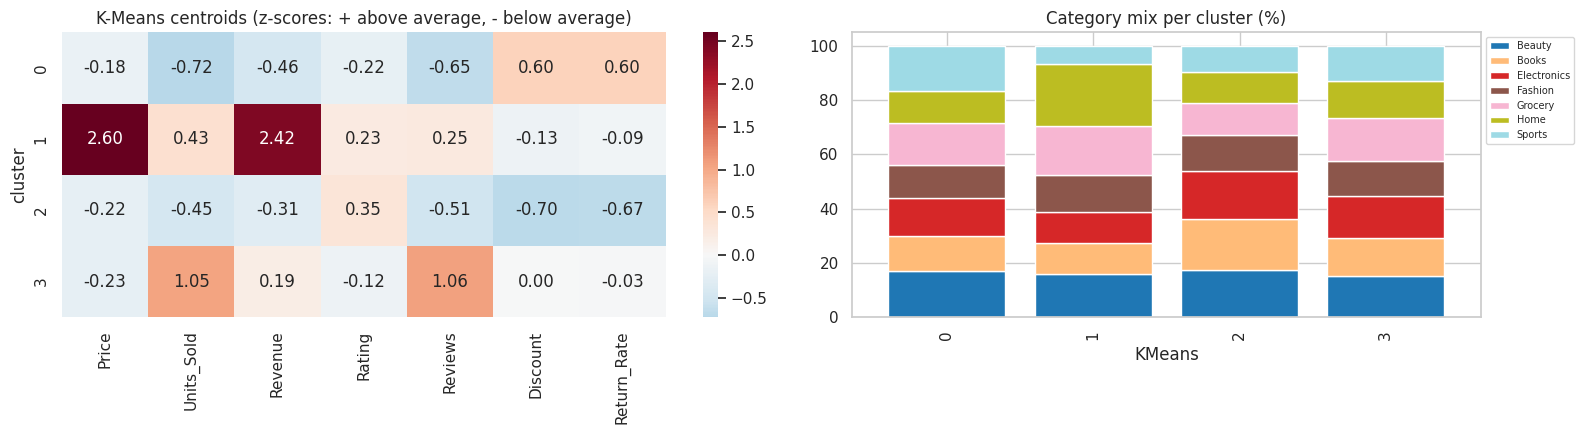

In [23]:
profile = df.groupby("KMeans")[CLUSTER_FEATURES].mean()
profile["Products"] = df.groupby("KMeans").size()
profile["Product_%"] = profile.Products / len(df) * 100
profile["Revenue_share_%"] = df.groupby("KMeans").Revenue.sum() / df.Revenue.sum() * 100
display(profile)

cz = pd.DataFrame(kmeans.cluster_centers_, columns=CLUSTER_FEATURES)   # centroid z-scores
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1.2, 1]})
sns.heatmap(cz, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("K-Means centroids (z-scores: + above average, - below average)"); axes[0].set_ylabel("cluster")
mix = pd.crosstab(df.KMeans, df.Category, normalize="index") * 100
mix.plot.bar(stacked=True, ax=axes[1], colormap="tab20", width=.8); axes[1].set_title("Category mix per cluster (%)"); axes[1].legend(fontsize=7, bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

,Products,Price,Units_Sold,Revenue,Rating,Reviews,Discount,Return_Rate,Revenue_share_%
Segment,,,,,,,,,
High-Demand,191,"3,259.14","2,404.56","5,827,571.65",4.03,"1,124.69",25.86,5.76,39.57
Premium,44,"13,890.08","1,874.89","18,879,459.94",4.19,736.84,24.07,5.63,29.53
Regular,165,"3,294.07","1,121.16","2,881,951.68",4.24,371.62,16.05,4.45,16.90
Low-Performing,200,"3,448.07",883.42,"1,968,629.62",3.99,300.44,34.25,7.02,14.00


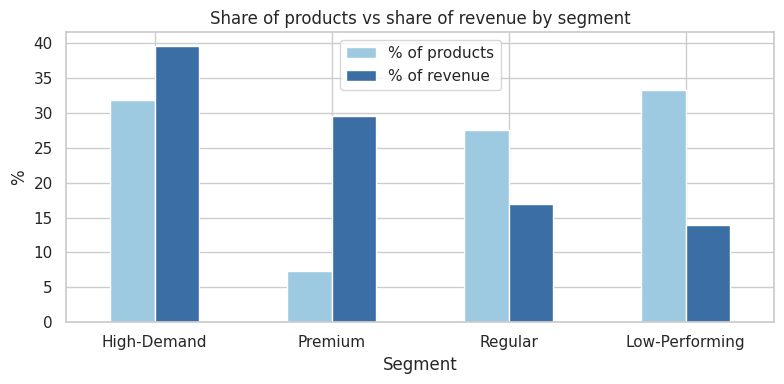

In [24]:
# Rule-based, reproducible labelling from the centroid z-scores
labels = {}
premium = cz.Price.idxmax();                                   labels[premium] = "Premium"
rest = cz.drop(index=premium)
high_demand = (rest.Units_Sold + rest.Reviews).idxmax();       labels[high_demand] = "High-Demand"
rest = rest.drop(index=high_demand)
low_perf = (rest.Discount + rest.Return_Rate).idxmax();        labels[low_perf] = "Low-Performing"
for c in rest.drop(index=low_perf).index:                      labels[c] = "Regular"

df["Segment"] = df.KMeans.map(labels)
seg_order = ["High-Demand", "Premium", "Regular", "Low-Performing"]
seg = df.groupby("Segment")[CLUSTER_FEATURES].mean().loc[seg_order]
seg.insert(0, "Products", df.Segment.value_counts().loc[seg_order])
seg["Revenue_share_%"] = df.groupby("Segment").Revenue.sum().loc[seg_order] / df.Revenue.sum() * 100
display(seg)

fig, ax = plt.subplots(figsize=(8, 4))
share = pd.DataFrame({"% of products": seg.Products / len(df) * 100, "% of revenue": seg["Revenue_share_%"]})
share.plot.bar(ax=ax, color=["#9ecae1", "#3b6ea5"]); ax.set_ylabel("%"); ax.set_title("Share of products vs share of revenue by segment"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [25]:
d_u = df[["Discount", "Units_Sold"]].corr().iloc[0, 1]
lp, pr, hd, rg = (seg.loc[s] for s in ["Low-Performing", "Premium", "High-Demand", "Regular"])
actions = pd.DataFrame({
    "Business meaning": [
        f"Fast movers: {hd.Units_Sold:,.0f} units and {hd.Reviews:,.0f} reviews on average, typical price (~{hd.Price:,.0f})",
        f"High price (~{pr.Price:,.0f}), solid volume, and the largest revenue per product (~{pr.Revenue/1e6:,.1f}M)",
        f"Healthy but modest sellers: {rg.Units_Sold:,.0f} units, yet the lowest discount ({rg.Discount:.0f}%), lowest returns ({rg.Return_Rate:.1f}%) and best rating ({rg.Rating:.2f})",
        f"Lowest volume ({lp.Units_Sold:,.0f} units) and revenue, yet the deepest discounts ({lp.Discount:.0f}%) and highest returns ({lp.Return_Rate:.1f}%)"],
    "Recommended actions": [
        "Keep deep safety stock and prioritise supply; feature on home/landing pages; bundle and cross-sell; hold prices (demand is not price-driven).",
        "Protect margin - avoid blanket discounting; invest in quality assurance, premium merchandising and targeted campaigns; monitor stock for fewer but costlier sales.",
        "Maintain steady replenishment; these are the best growth candidates (good ratings, low returns, little discounting) - test more visibility, ads and bundles; watch for products that can graduate to High-Demand.",
        "Investigate quality / listing accuracy behind the high returns; cut discounts that are not lifting sales; reduce stock, run clearance bundles, and review for delisting."]},
    index=pd.Index(seg_order, name="Segment"))
pd.set_option("display.max_colwidth", 200)
display(actions)
print(f"Evidence that discounting is not the lever: corr(Discount, Units_Sold) = {d_u:.2f} across all products.")
print(f"{int(((df.Segment == 'Premium') & df.Outlier_DBSCAN).sum())} of the {int(df.Outlier_DBSCAN.sum())} DBSCAN outliers fall in the Premium segment.")

,Business meaning,Recommended actions
Segment,,
High-Demand,"Fast movers: 2,405 units and 1,125 reviews on average, typical price (~3,259)",Keep deep safety stock and prioritise supply; feature on home/landing pages; bundle and cross-sell; hold prices (demand is not price-driven).
Premium,"High price (~13,890), solid volume, and the largest revenue per product (~18.9M)","Protect margin - avoid blanket discounting; invest in quality assurance, premium merchandising and targeted campaigns; monitor stock for fewer but costlier sales."
Regular,"Healthy but modest sellers: 1,121 units, yet the lowest discount (16%), lowest returns (4.4%) and best rating (4.24)","Maintain steady replenishment; these are the best growth candidates (good ratings, low returns, little discounting) - test more visibility, ads and bundles; watch for products that can graduate to High-Demand."
Low-Performing,"Lowest volume (883 units) and revenue, yet the deepest discounts (34%) and highest returns (7.0%)","Investigate quality / listing accuracy behind the high returns; cut discounts that are not lifting sales; reduce stock, run clearance bundles, and review for delisting."


Evidence that discounting is not the lever: corr(Discount, Units_Sold) = -0.05 across all products.
25 of the 31 DBSCAN outliers fall in the Premium segment.


In [26]:
# Save the result for use in Excel / BI tools
out_cols = ["Product_ID", "Product_Name", "Category"] + CLUSTER_FEATURES + ["Segment", "KMeans", "Hierarchical", "GMM", "Outlier_DBSCAN"]
df[out_cols].to_csv("products_with_segments.csv", index=False)
print("Saved products_with_segments.csv with", len(df), "rows")

Saved products_with_segments.csv with 600 rows


## 4.4 Supplementary model – Linear Regression (predict `Revenue`)
Clustering remains the project's core method. This supervised model gives a labelled task on which to demonstrate the validation concepts in Section 5, and shows which features drive revenue.

- **Target:** `Revenue`  **Predictors:** `Price`, `Units_Sold`, `Rating`, `Reviews`, `Discount`, `Return_Rate`, one-hot `Category`.
- **Split:** 80 % train (480 products) / 20 % test (120 products).
- **Scaling:** `StandardScaler` is inside a pipeline, so it is fitted on the training data only.

In [27]:
TARGET = "Revenue"
REG_NUMERIC = ["Price", "Units_Sold", "Rating", "Reviews", "Discount", "Return_Rate"]
X_reg = pd.get_dummies(df[REG_NUMERIC + ["Category"]], columns=["Category"], drop_first=True, dtype=float)
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X_reg, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

lin = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)

def reg_metrics(model, Xa, ya):
    p = model.predict(Xa)
    return {"R2": r2_score(ya, p), "RMSE": np.sqrt(mean_squared_error(ya, p)), "MAE": mean_absolute_error(ya, p)}

res = pd.DataFrame({"Train": reg_metrics(lin, X_train, y_train), "Test": reg_metrics(lin, X_test, y_test)}).T
display(res)

Train: (480, 12)  Test: (120, 12)


,R2,RMSE,MAE
Train,0.83,"2,277,304.72","1,434,628.24"
Test,0.73,"3,668,380.60","1,895,016.82"


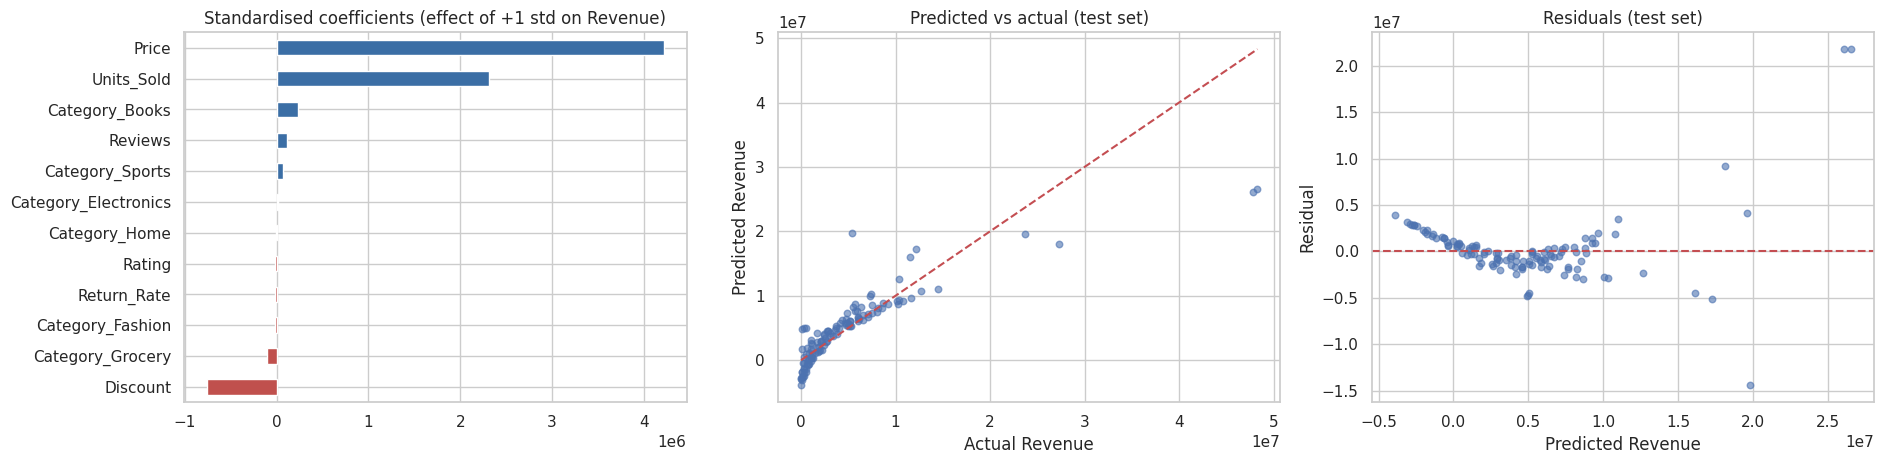

21 of 120 test predictions are negative, although revenue can never be negative.


,standardised coefficient
Price,"4,218,482.70"
Units_Sold,"2,318,581.28"
Category_Books,"232,627.19"
Reviews,"107,243.09"
Category_Sports,"65,398.63"
Category_Electronics,"8,581.96"
Category_Home,"-3,942.71"
Rating,"-15,037.00"
Return_Rate,"-15,638.76"
Category_Fashion,"-24,214.16"


In [28]:
coef = pd.Series(lin[-1].coef_, index=X_reg.columns).sort_values()
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
coef.plot.barh(ax=axes[0], color=np.where(coef > 0, "#3b6ea5", "#c0504d")); axes[0].set_title("Standardised coefficients (effect of +1 std on Revenue)")
pred = lin.predict(X_test)
axes[1].scatter(y_test, pred, alpha=.6, s=22); lim = [0, max(y_test.max(), pred.max())]
axes[1].plot(lim, lim, "r--"); axes[1].set_xlabel("Actual Revenue"); axes[1].set_ylabel("Predicted Revenue"); axes[1].set_title("Predicted vs actual (test set)")
axes[2].scatter(pred, y_test - pred, alpha=.6, s=22); axes[2].axhline(0, color="r", ls="--")
axes[2].set_xlabel("Predicted Revenue"); axes[2].set_ylabel("Residual"); axes[2].set_title("Residuals (test set)")
plt.tight_layout(); plt.show()
print(f"{(pred < 0).sum()} of {len(pred)} test predictions are negative, although revenue can never be negative.")
display(coef.sort_values(ascending=False).to_frame("standardised coefficient"))

In [29]:
abs_err = np.abs(y_test - pred)
hi = pred >= np.median(pred)
display(Markdown(f"""
**Reading the regression**
- `Price` and `Units_Sold` are by far the strongest drivers of revenue (standardised coefficients {coef['Price']:,.0f} and {coef['Units_Sold']:,.0f}). `Discount` comes next with a *negative* sign ({coef['Discount']:,.0f}): a deeper discount lowers revenue per unit. `Reviews`, `Rating`, `Return_Rate` and the category dummies have much smaller effects (no coefficient larger than {coef.drop(['Price', 'Units_Sold', 'Discount']).abs().max():,.0f} in absolute value).
- The model explains {r2_score(y_test, pred):.0%} of the variance on the test set (train {lin.score(X_train, y_train):.0%}). Errors are larger for big sellers: the mean absolute error is {abs_err[hi].mean():,.0f} for products with above-median predicted revenue versus {abs_err[~hi].mean():,.0f} below the median.
- {(pred < 0).sum()} of {len(pred)} test predictions are negative, which is impossible for revenue.
- Given Section 2.1, the remaining error is **not noise**: it exists because a straight-line (additive) model cannot represent `Price x Units x (1 - Discount)`. This under-fitting is examined in Section 5.2.
"""))


**Reading the regression**
- `Price` and `Units_Sold` are by far the strongest drivers of revenue (standardised coefficients 4,218,483 and 2,318,581). `Discount` comes next with a *negative* sign (-757,495): a deeper discount lowers revenue per unit. `Reviews`, `Rating`, `Return_Rate` and the category dummies have much smaller effects (no coefficient larger than 232,627 in absolute value).
- The model explains 73% of the variance on the test set (train 83%). Errors are larger for big sellers: the mean absolute error is 2,581,612 for products with above-median predicted revenue versus 1,208,422 below the median.
- 21 of 120 test predictions are negative, which is impossible for revenue.
- Given Section 2.1, the remaining error is **not noise**: it exists because a straight-line (additive) model cannot represent `Price x Units x (1 - Discount)`. This under-fitting is examined in Section 5.2.


---
# 5. Model Validation and Generalization

## 5.1 Cross-validation

### Regression - 5-fold cross-validation (target: `Revenue`)
The training data is split into 5 folds; the model trains on 4 and is scored on the 5th, rotating through all 5. Scores are averaged. This is more reliable than a single split because the result no longer depends on which rows landed in the test set.

In [30]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv = cross_validate(lin, X_train, y_train, cv=kf,
                    scoring={"r2": "r2", "neg_rmse": "neg_root_mean_squared_error"}, return_train_score=True)
folds = pd.DataFrame({"Train R2": cv["train_r2"], "Validation R2": cv["test_r2"], "Validation RMSE": -cv["test_neg_rmse"]},
                     index=[f"Fold {i}" for i in range(1, 6)])
folds.loc["Mean"] = folds.mean(); folds.loc["Std"] = folds.iloc[:5].std()
display(folds)

test_r2_holdout = lin.score(X_test, y_test)
print(f"5-fold CV R2 = {cv['test_r2'].mean():.3f} (+/- {cv['test_r2'].std():.3f});  hold-out test R2 = {test_r2_holdout:.3f}")

,Train R2,Validation R2,Validation RMSE
Fold 1,0.81,0.89,"1,999,755.34"
Fold 2,0.83,0.80,"1,871,692.59"
Fold 3,0.83,0.77,"2,452,824.31"
Fold 4,0.84,0.76,"2,906,291.93"
Fold 5,0.84,0.79,"2,701,119.52"
Mean,0.83,0.80,"2,386,336.74"
Std,0.01,0.05,"443,893.56"


5-fold CV R2 = 0.802 (+/- 0.046);  hold-out test R2 = 0.735


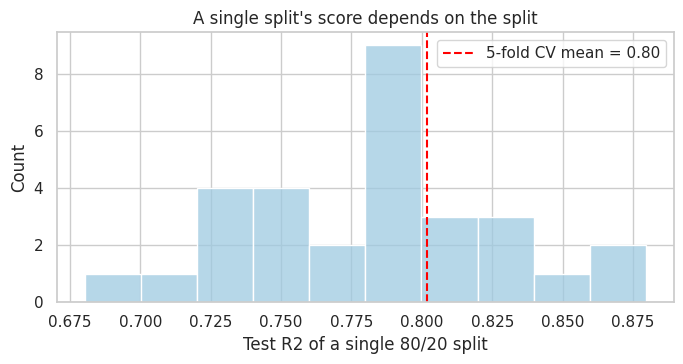

Across 30 random splits, test R2 ranges from 0.680 to 0.880 (std 0.045).
Our hold-out test R2 (0.735) vs the 5-fold CV mean (0.802): the CV mean is the steadier estimate.


In [31]:
# How much does one single train/test split depend on luck?  Repeat the 80/20 split with 30 different seeds.
split_r2 = []
for seed in range(30):
    Xa, Xb, ya, yb = train_test_split(X_reg, y, test_size=0.2, random_state=seed)
    split_r2.append(make_pipeline(StandardScaler(), LinearRegression()).fit(Xa, ya).score(Xb, yb))
split_r2 = np.array(split_r2)

fig, ax = plt.subplots(figsize=(7, 3.8))
sns.histplot(split_r2, bins=10, ax=ax, color="#9ecae1")
ax.axvline(cv["test_r2"].mean(), color="red", ls="--", label=f"5-fold CV mean = {cv['test_r2'].mean():.2f}")
ax.set_xlabel("Test R2 of a single 80/20 split"); ax.set_title("A single split's score depends on the split"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Across 30 random splits, test R2 ranges from {split_r2.min():.3f} to {split_r2.max():.3f} (std {split_r2.std():.3f}).")
print(f"Our hold-out test R2 ({test_r2_holdout:.3f}) vs the 5-fold CV mean ({cv['test_r2'].mean():.3f}): the CV mean is the steadier estimate.")

### Clustering - stability analysis
Clustering has no labels to cross-validate against, so its analogue is **stability**: do we get the same segments when the random start or the sample changes? The **Adjusted Rand Index (ARI)** measures agreement between two labelings (1 = identical, 0 = random). For each individual segment, the **Jaccard similarity** measures how well that segment's members are recovered after resampling (rule of thumb: below 0.5 the segment has essentially dissolved, 0.6-0.75 indicates a real pattern, 0.85+ is highly stable).

In [32]:
ref = kmeans.labels_

# (a) different random initialisations (a single init each, so poor local optima are visible)
seed_ari, seed_inertia = [], []
for s in range(30):
    km = KMeans(n_clusters=K_FINAL, n_init=1, random_state=s).fit(Z)
    seed_ari.append(adjusted_rand_score(ref, km.labels_)); seed_inertia.append(km.inertia_)
seed_ari = np.array(seed_ari)
print(f"(a) 30 single random initialisations: mean ARI vs final model = {seed_ari.mean():.2f}, min = {seed_ari.min():.2f}; "
      f"{(seed_ari > 0.9).mean():.0%} of runs reproduce the final segmentation almost exactly (ARI > 0.9)")
print(f"    WCSS over seeds: {min(seed_inertia):,.0f} - {max(seed_inertia):,.0f}; the final model (best of 20 starts) has {kmeans.inertia_:,.0f}, i.e. the best value found.")

# (b) bootstrap resamples: refit on a resample, then label ALL products and compare with the reference
rng = np.random.default_rng(RANDOM_STATE)
def bootstrap_stability(k, B=30):
    ref_k = KMeans(k, n_init=20, random_state=RANDOM_STATE).fit(Z).labels_
    aris = []
    for b in range(B):
        idx = rng.choice(len(Z), len(Z), replace=True)
        km = KMeans(k, n_init=5, random_state=b).fit(Z[idx])
        aris.append(adjusted_rand_score(ref_k, km.predict(Z)))
    return np.mean(aris), np.std(aris)

stab = pd.DataFrame([{"K": k, **dict(zip(["Mean_ARI", "Std_ARI"], bootstrap_stability(k)))} for k in K_RANGE]).set_index("K")
stab["Smallest_cluster"] = k_table.Smallest_cluster
print("\n(b) Bootstrap stability (30 resamples) by K:")
display(stab)

# (c) is the chosen K itself stable? pick K by silhouette on 30 bootstrap samples
picked = []
for b in range(30):
    idx = rng.choice(len(Z), len(Z), replace=True)
    sc = {k: silhouette_score(Z[idx], KMeans(k, n_init=5, random_state=b).fit_predict(Z[idx])) for k in range(2, 9)}
    picked.append(max(sc, key=sc.get))
picked_counts = {int(k): int(v) for k, v in pd.Series(picked).value_counts().sort_index().items()}
print("(c) K chosen by max silhouette on 30 bootstrap samples:", picked_counts)

(a) 30 single random initialisations: mean ARI vs final model = 0.67, min = 0.32; 33% of runs reproduce the final segmentation almost exactly (ARI > 0.9)
    WCSS over seeds: 2,517 - 2,819; the final model (best of 20 starts) has 2,517, i.e. the best value found.

(b) Bootstrap stability (30 resamples) by K:


,Mean_ARI,Std_ARI,Smallest_cluster
K,,,
2,0.81,0.17,233
3,0.82,0.12,44
4,0.58,0.17,44
5,0.57,0.17,35
6,0.56,0.09,9
7,0.50,0.09,8
8,0.50,0.10,9
9,0.46,0.08,8
10,0.44,0.09,7


(c) K chosen by max silhouette on 30 bootstrap samples: {2: 23, 3: 7}


In [33]:
# (d) per-segment stability (cluster-wise Jaccard) for the final K = 4 segmentation
def segment_jaccard(k, ref_labels, B=30):
    rng_ = np.random.default_rng(RANDOM_STATE + 1)
    scores = {c: [] for c in np.unique(ref_labels)}
    for b in range(B):
        idx = rng_.choice(len(Z), len(Z), replace=True)
        pred = KMeans(k, n_init=5, random_state=b).fit(Z[idx]).predict(Z)
        for c in scores:
            A = ref_labels == c
            scores[c].append(max((A & (pred == d)).sum() / (A | (pred == d)).sum() for d in np.unique(pred)))
    return {c: float(np.mean(v)) for c, v in scores.items()}

jac = segment_jaccard(K_FINAL, ref)
jac_table = pd.DataFrame({"Segment": [labels[c] for c in sorted(jac)], "Products": [int((ref == c).sum()) for c in sorted(jac)],
                          "Mean Jaccard": [jac[c] for c in sorted(jac)]}).set_index("Segment").loc[seg_order]
display(jac_table)

,Products,Mean Jaccard
Segment,,
High-Demand,191,0.75
Premium,44,0.78
Regular,165,0.64
Low-Performing,200,0.67


In [34]:
display(Markdown(f"""
**What the stability analysis says (honestly)**
- **Final model vs random starts:** a single random start reproduces the final segmentation almost exactly in only {(seed_ari > 0.9).mean():.0%} of runs (mean ARI {seed_ari.mean():.2f}), because K-Means can land in worse local optima. That is why the final model uses the **best of 20 starts** - it has the lowest WCSS found.
- **Resampling products:** bootstrap agreement is **ARI = {stab.loc[4,'Mean_ARI']:.2f} at K = 4**, lower than at K = 2 ({stab.loc[2,'Mean_ARI']:.2f}) or K = 3 ({stab.loc[3,'Mean_ARI']:.2f}). So K = 4 is a *moderately* stable segmentation - consistent with the low silhouette: segment boundaries are fuzzy.
- **Is K itself stable?** Silhouette on bootstrap samples picks K = 2 in {picked_counts.get(2,0)} of 30 resamples and K = 3 in {picked_counts.get(3,0)}; K = 4 is picked in {picked_counts.get(4,0)}. Choosing K = 4 is therefore a deliberate *business-interpretability* decision, not a purely statistical one.
- **Segment by segment:** the Jaccard scores above show which segments to trust most: **{jac_table['Mean Jaccard'].idxmax()}** is the most stable ({jac_table['Mean Jaccard'].max():.2f}) and **{jac_table['Mean Jaccard'].idxmin()}** the least ({jac_table['Mean Jaccard'].min():.2f}). {'All four segments are above 0.6, so each reflects a real pattern, but none reaches the 0.85 "highly stable" level.' if jac_table['Mean Jaccard'].min() >= 0.6 else 'At least one segment is below 0.6 and should be treated with caution.'}
"""))


**What the stability analysis says (honestly)**
- **Final model vs random starts:** a single random start reproduces the final segmentation almost exactly in only 33% of runs (mean ARI 0.67), because K-Means can land in worse local optima. That is why the final model uses the **best of 20 starts** - it has the lowest WCSS found.
- **Resampling products:** bootstrap agreement is **ARI = 0.58 at K = 4**, lower than at K = 2 (0.81) or K = 3 (0.82). So K = 4 is a *moderately* stable segmentation - consistent with the low silhouette: segment boundaries are fuzzy.
- **Is K itself stable?** Silhouette on bootstrap samples picks K = 2 in 23 of 30 resamples and K = 3 in 7; K = 4 is picked in 0. Choosing K = 4 is therefore a deliberate *business-interpretability* decision, not a purely statistical one.
- **Segment by segment:** the Jaccard scores above show which segments to trust most: **Premium** is the most stable (0.78) and **Regular** the least (0.64). All four segments are above 0.6, so each reflects a real pattern, but none reaches the 0.85 "highly stable" level.


## 5.2 Overfitting and underfitting

### Regression, part 1 - underfitting (target: `Revenue`)
Revenue is the review's regression target, but Section 2.1 showed that it is an exact formula, `Price × Units_Sold × (1 − Discount/100)`. That makes it ideal for showing **underfitting** and the role of model form:
- *Underfit:* uses only `Rating` + `Discount` (little relation to revenue).
- *Linear (all features):* the model from Section 4.4 - a sum of terms cannot represent a *product* of variables.
- *Log form:* the same linear regression, but on `log(Revenue)` with `log(Price)`, `log(Units_Sold)` and `log(1 − Discount/100)` - the formula made linear.
- *Polynomial degree 3:* flexible enough to contain the product term `Price × Units × Discount`.

In [35]:
def log_pct_remaining(x):
    return np.log(1 - x / 100)

def make_log_form():
    return TransformedTargetRegressor(
        regressor=make_pipeline(ColumnTransformer([("logPU", FunctionTransformer(np.log), ["Price", "Units_Sold"]),
                                                   ("logD", FunctionTransformer(log_pct_remaining), ["Discount"])], remainder="drop"),
                                LinearRegression()),
        func=np.log, inverse_func=np.exp)

def poly_model(deg, num_cols):
    pre = ColumnTransformer([("poly", make_pipeline(StandardScaler(), PolynomialFeatures(deg, include_bias=False)), num_cols)],
                            remainder="passthrough")
    return make_pipeline(pre, StandardScaler(), LinearRegression())

def evaluate(models, Xtr, ytr, Xte, yte):
    rows = []
    for name, (mdl, cols) in models.items():
        A = Xtr if cols is None else Xtr[cols]; B = Xte if cols is None else Xte[cols]
        c = cross_validate(mdl, A, ytr, cv=kf, scoring="r2", return_train_score=True)
        mdl.fit(A, ytr)
        tr_r2 = mdl.score(A, ytr)
        rows.append({"Model": name, "Train R2": tr_r2, "CV R2": c["test_score"].mean(), "Test R2": mdl.score(B, yte),
                     "Train-CV gap": tr_r2 - c["test_score"].mean()})
    return pd.DataFrame(rows).set_index("Model")

def show3(tbl):
    display(tbl.apply(lambda col: col.map("{:.3f}".format)))

LOG_FORM = "Log form (log P, log U, log(1-Disc))"
rev_models = {
    "Underfit: Rating + Discount only": (make_pipeline(StandardScaler(), LinearRegression()), ["Rating", "Discount"]),
    "Linear (all features)": (make_pipeline(StandardScaler(), LinearRegression()), None),
    LOG_FORM: (make_log_form(), None),
    "Polynomial degree 3": (poly_model(3, REG_NUMERIC), None),
}
rev_ladder = evaluate(rev_models, X_train, y_train, X_test, y_test)
show3(rev_ladder)

,Train R2,CV R2,Test R2,Train-CV gap
Model,,,,
Underfit: Rating + Discount only,0.030,0.012,0.030,0.018
Linear (all features),0.828,0.802,0.735,0.026
"Log form (log P, log U, log(1-Disc))",1.000,1.000,1.000,0.000
Polynomial degree 3,1.000,1.000,1.000,0.000


In [36]:
r = rev_ladder
display(Markdown(f"""
**What this shows**
- **Underfitting (wrong inputs):** with only `Rating` and `Discount`, R2 is {r.iloc[0]['Train R2']:.2f} on train and {r.iloc[0]['Test R2']:.2f} on test - poor on *both*.
- **Underfitting (wrong form):** the linear model on all features reaches CV R2 = {r.loc['Linear (all features)','CV R2']:.2f} / test R2 = {r.loc['Linear (all features)','Test R2']:.2f} with a modest train-CV gap ({r.loc['Linear (all features)','Train-CV gap']:.2f}). Its training score is itself only {r.loc['Linear (all features)','Train R2']:.2f} - a high-bias model that cannot represent a product of variables.
- **Fixing the bias:** the log form reaches CV R2 = {r.loc[LOG_FORM,'CV R2']:.3f} with *fewer* parameters. This is the formula being recovered, not "prediction" in the usual sense.
- **Why polynomials are not used to show over-fitting here:** degree 3 already scores CV R2 = {r.loc['Polynomial degree 3','CV R2']:.3f}, because the exact formula is built from degree-3 terms. A flexible model cannot over-fit a noise-free target, so over-fitting is demonstrated on a noisy target next.
"""))


**What this shows**
- **Underfitting (wrong inputs):** with only `Rating` and `Discount`, R2 is 0.03 on train and 0.03 on test - poor on *both*.
- **Underfitting (wrong form):** the linear model on all features reaches CV R2 = 0.80 / test R2 = 0.73 with a modest train-CV gap (0.03). Its training score is itself only 0.83 - a high-bias model that cannot represent a product of variables.
- **Fixing the bias:** the log form reaches CV R2 = 1.000 with *fewer* parameters. This is the formula being recovered, not "prediction" in the usual sense.
- **Why polynomials are not used to show over-fitting here:** degree 3 already scores CV R2 = 1.000, because the exact formula is built from degree-3 terms. A flexible model cannot over-fit a noise-free target, so over-fitting is demonstrated on a noisy target next.


### Regression, part 2 - overfitting (second target: `Units_Sold`)
`Units_Sold` has no exact formula - it is only partly explained by the other columns - so flexible models can chase noise. It is predicted from `Price`, `Rating`, `Reviews`, `Discount`, `Return_Rate` and one-hot `Category` (`Revenue` is excluded because it is built from `Units_Sold`). The polynomial degree is the "flexibility dial".

,Train R2,CV R2,Test R2,Train-CV gap
Model,,,,
Underfit: Rating + Discount only,0.004,-0.034,-0.014,0.038
Linear (degree 1),0.606,0.579,0.571,0.027
Polynomial degree 2,0.652,0.598,0.608,0.054
Polynomial degree 3,0.671,0.481,0.597,0.190
Polynomial degree 4,0.713,-4.908,0.083,5.621


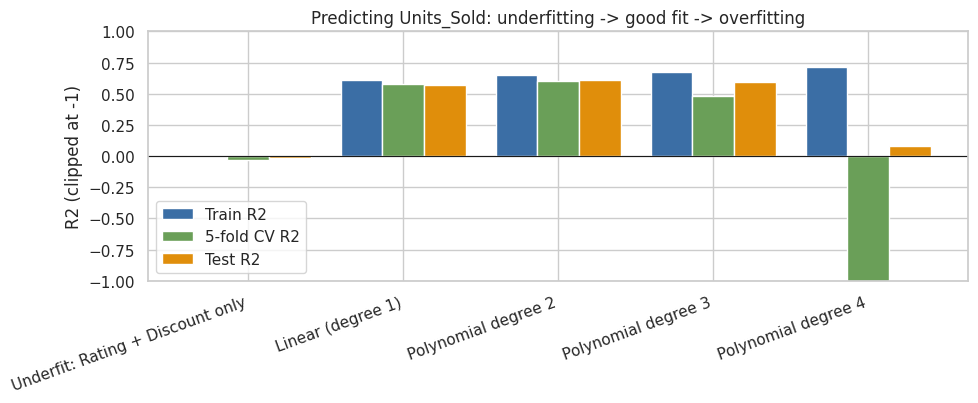

In [37]:
U_NUM = ["Price", "Rating", "Reviews", "Discount", "Return_Rate"]
X_u = pd.get_dummies(df[U_NUM + ["Category"]], columns=["Category"], drop_first=True, dtype=float)
y_u = df["Units_Sold"]
Xu_train, Xu_test, yu_train, yu_test = train_test_split(X_u, y_u, test_size=0.2, random_state=RANDOM_STATE)

units_models = {
    "Underfit: Rating + Discount only": (make_pipeline(StandardScaler(), LinearRegression()), ["Rating", "Discount"]),
    "Linear (degree 1)": (make_pipeline(StandardScaler(), LinearRegression()), None),
    "Polynomial degree 2": (poly_model(2, U_NUM), None),
    "Polynomial degree 3": (poly_model(3, U_NUM), None),
    "Polynomial degree 4": (poly_model(4, U_NUM), None),
}
units_ladder = evaluate(units_models, Xu_train, yu_train, Xu_test, yu_test)
show3(units_ladder)

fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(units_ladder)); w = .27
ax.bar(x - w, units_ladder["Train R2"].clip(-1, 1), w, label="Train R2", color="#3b6ea5")
ax.bar(x, units_ladder["CV R2"].clip(-1, 1), w, label="5-fold CV R2", color="#6a9f58")
ax.bar(x + w, units_ladder["Test R2"].clip(-1, 1), w, label="Test R2", color="#e08e0b")
ax.set_xticks(x); ax.set_xticklabels(units_ladder.index, rotation=20, ha="right"); ax.axhline(0, color="k", lw=.8)
ax.set_ylim(-1, 1); ax.set_ylabel("R2 (clipped at -1)"); ax.set_title("Predicting Units_Sold: underfitting -> good fit -> overfitting"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

In [38]:
u = units_ladder
display(Markdown(f"""
**What this shows**
- **Underfitting:** `Rating` + `Discount` alone give R2 = {u.iloc[0]['Train R2']:.2f} (train) and {u.iloc[0]['CV R2']:.2f} (CV) - nothing useful is learned.
- **Good fit:** the plain linear model gives train {u.loc['Linear (degree 1)','Train R2']:.2f} / CV {u.loc['Linear (degree 1)','CV R2']:.2f} - almost no gap. Degree 2 is only slightly better (CV {u.loc['Polynomial degree 2','CV R2']:.2f}).
- **Overfitting:** training R2 keeps rising with degree ({u.loc['Polynomial degree 2','Train R2']:.2f} -> {u.loc['Polynomial degree 3','Train R2']:.2f} -> {u.loc['Polynomial degree 4','Train R2']:.2f}) while cross-validated R2 falls ({u.loc['Polynomial degree 2','CV R2']:.2f} -> {u.loc['Polynomial degree 3','CV R2']:.2f} -> {u.loc['Polynomial degree 4','CV R2']:.1f}); the degree-4 test R2 is only {u.loc['Polynomial degree 4','Test R2']:.2f}. Looking at training R2 alone would wrongly suggest degree 4 is best - which is why train and CV scores are reported together.
"""))


**What this shows**
- **Underfitting:** `Rating` + `Discount` alone give R2 = 0.00 (train) and -0.03 (CV) - nothing useful is learned.
- **Good fit:** the plain linear model gives train 0.61 / CV 0.58 - almost no gap. Degree 2 is only slightly better (CV 0.60).
- **Overfitting:** training R2 keeps rising with degree (0.65 -> 0.67 -> 0.71) while cross-validated R2 falls (0.60 -> 0.48 -> -4.9); the degree-4 test R2 is only 0.08. Looking at training R2 alone would wrongly suggest degree 4 is best - which is why train and CV scores are reported together.


### Clustering - K too small vs K too large
For clustering, K too small merges different product types (underfitting); K too large splits the data into tiny, unstable clusters (overfitting). The plots show the second effect: as K grows, the smallest cluster shrinks to a handful of products and agreement between bootstrap refits (ARI) falls, while WCSS keeps improving - training fit *always* improves with K, which is why it cannot be used alone to choose K.

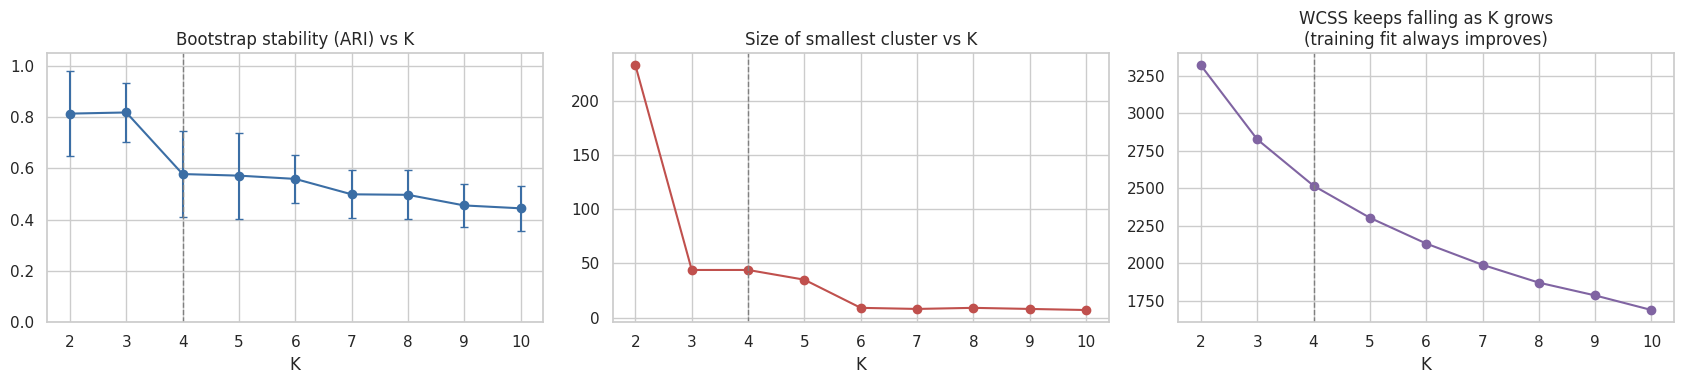

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].errorbar(stab.index, stab.Mean_ARI, yerr=stab.Std_ARI, marker="o", capsize=3, color="#3b6ea5")
axes[0].set_title("Bootstrap stability (ARI) vs K"); axes[0].set_xlabel("K"); axes[0].set_ylim(0, 1.05)
axes[1].plot(stab.index, stab.Smallest_cluster, marker="o", color="#c0504d"); axes[1].set_title("Size of smallest cluster vs K"); axes[1].set_xlabel("K")
axes[2].plot(k_table.index, k_table.WCSS, marker="o", color="#8064a2"); axes[2].set_title("WCSS keeps falling as K grows\n(training fit always improves)"); axes[2].set_xlabel("K")
for a in axes: a.axvline(K_FINAL, ls="--", color="grey", lw=1)
plt.tight_layout(); plt.show()

## 5.3 Bias–variance trade-off
**Bias** = systematic error from a model being too simple; **variance** = sensitivity to *which* products were in the training set. To measure both, each model is refitted on 40 bootstrap resamples of the training data and used to predict the same held-out products:
- *Bias* = RMS gap between the **average** prediction and the truth (it includes irreducible noise, so compare models relative to each other).
- *Variance (spread)* = how much predictions **move** between refits (RMS standard deviation).

The noisy `Units_Sold` task is used for the model comparison; the `Revenue` task is used afterwards to show a pure *bias* problem.

,Bias (RMS),Variance spread (RMS),Train R2,CV R2
Model,,,,
Linear (degree 1),573.0,81.2,0.61,0.58
Polynomial degree 3,556.9,312.3,0.68,0.48
Polynomial degree 4,912.4,"2,537.6",0.74,-4.91
Decision tree (depth 3),544.1,186.9,0.68,0.60
Decision tree (unlimited),543.0,514.4,1.00,0.26
Random forest,533.6,169.6,0.94,0.56


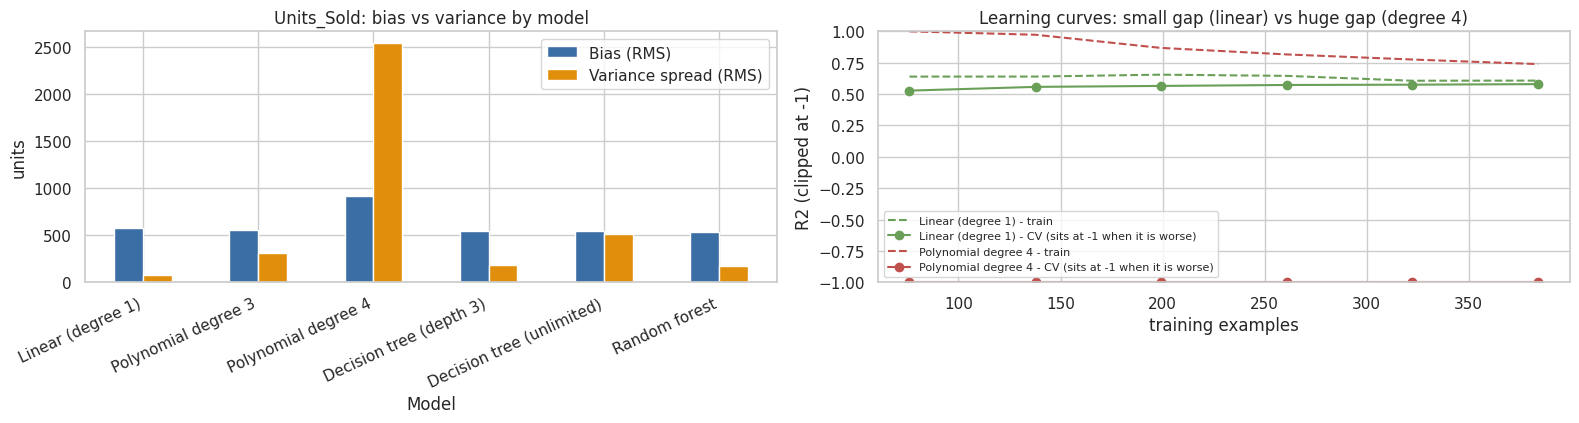

In [40]:
rng = np.random.default_rng(RANDOM_STATE)
def bias_variance(factory, Xtr, ytr, Xte, yte, B=40):
    preds = np.empty((B, len(Xte)))
    for b in range(B):
        idx = rng.choice(len(Xtr), len(Xtr), replace=True)
        preds[b] = factory().fit(Xtr.iloc[idx], ytr.iloc[idx]).predict(Xte)
    return np.sqrt(np.mean((preds.mean(0) - yte.values) ** 2)), np.sqrt(np.mean(preds.var(0)))

factories = {
    "Linear (degree 1)": lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "Polynomial degree 3": lambda: poly_model(3, U_NUM),
    "Polynomial degree 4": lambda: poly_model(4, U_NUM),
    "Decision tree (depth 3)": lambda: DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    "Decision tree (unlimited)": lambda: DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random forest": lambda: RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}
rows = []
for name, f in factories.items():
    b_, v_ = bias_variance(f, Xu_train, yu_train, Xu_test, yu_test)
    c = cross_validate(f(), Xu_train, yu_train, cv=kf, scoring="r2", return_train_score=True)
    rows.append({"Model": name, "Bias (RMS)": b_, "Variance spread (RMS)": v_,
                 "Train R2": c["train_score"].mean(), "CV R2": c["test_score"].mean()})
bv = pd.DataFrame(rows).set_index("Model")
display(bv.apply(lambda col: col.map("{:,.2f}".format) if col.name.endswith("R2") else col.map("{:,.1f}".format)))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.4))
bv[["Bias (RMS)", "Variance spread (RMS)"]].plot.bar(ax=axes[0], color=["#3b6ea5", "#e08e0b"])
axes[0].set_title("Units_Sold: bias vs variance by model"); axes[0].set_ylabel("units")
axes[0].set_xticklabels(bv.index, rotation=25, ha="right")
for mdl_name, color in [("Linear (degree 1)", "#6a9f58"), ("Polynomial degree 4", "#c0504d")]:
    sizes, tr, va = learning_curve(factories[mdl_name](), Xu_train, yu_train, cv=kf, train_sizes=np.linspace(.2, 1, 6), scoring="r2")
    axes[1].plot(sizes, np.clip(tr.mean(1), -1, 1), "--", color=color, label=f"{mdl_name} - train")
    axes[1].plot(sizes, np.clip(va.mean(1), -1, 1), "-o", color=color, label=f"{mdl_name} - CV (sits at -1 when it is worse)")
axes[1].set_ylim(-1, 1); axes[1].set_xlabel("training examples"); axes[1].set_ylabel("R2 (clipped at -1)")
axes[1].set_title("Learning curves: small gap (linear) vs huge gap (degree 4)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [41]:
# Pure-bias example on the Revenue task: same data, two model forms
bias_rows = []
for name, f in {"Linear (all features)": lambda: make_pipeline(StandardScaler(), LinearRegression()), LOG_FORM: make_log_form}.items():
    b_, v_ = bias_variance(f, X_train, y_train, X_test, y_test)
    bias_rows.append({"Model": name, "Bias (RMS)": b_, "Variance spread (RMS)": v_})
rev_bv = pd.DataFrame(bias_rows).set_index("Model")
display(rev_bv.apply(lambda col: col.map("{:,.0f}".format)))

,Bias (RMS),Variance spread (RMS)
Model,,
Linear (all features),"3,667,199","467,887"
"Log form (log P, log U, log(1-Disc))",0,0


In [42]:
b = bv
display(Markdown(f"""
**Interpretation**
- **Linear regression** is the high-bias / low-variance end of the Units_Sold models: bias {b.loc['Linear (degree 1)','Bias (RMS)']:,.0f} units, spread only {b.loc['Linear (degree 1)','Variance spread (RMS)']:,.0f}.
- **Raising flexibility trades bias for variance:** the spread grows from {b.loc['Linear (degree 1)','Variance spread (RMS)']:,.0f} (linear) to {b.loc['Polynomial degree 3','Variance spread (RMS)']:,.0f} (degree 3) and {b.loc['Polynomial degree 4','Variance spread (RMS)']:,.0f} (degree 4), while CV R2 changes from {b.loc['Linear (degree 1)','CV R2']:.2f} to {b.loc['Polynomial degree 4','CV R2']:.1f}.
- **Decision trees:** the unlimited tree fits the training data perfectly (train R2 = {b.loc['Decision tree (unlimited)','Train R2']:.2f}) but its CV R2 is only {b.loc['Decision tree (unlimited)','CV R2']:.2f}, with spread {b.loc['Decision tree (unlimited)','Variance spread (RMS)']:,.0f}; limiting depth to 3 gives CV R2 {b.loc['Decision tree (depth 3)','CV R2']:.2f}, and averaging 100 trees (random forest) gives {b.loc['Random forest','CV R2']:.2f} with the spread cut from {b.loc['Decision tree (unlimited)','Variance spread (RMS)']:,.0f} to {b.loc['Random forest','Variance spread (RMS)']:,.0f} - averaging reduces variance.
- **Pure bias (Revenue task):** the linear model has bias {rev_bv.iloc[0]['Bias (RMS)']:,.0f} versus {rev_bv.iloc[1]['Bias (RMS)']:,.0f} for the log form (spread {rev_bv.iloc[0]['Variance spread (RMS)']:,.0f} vs {rev_bv.iloc[1]['Variance spread (RMS)']:,.0f}; the log form is essentially exact because it *is* the formula). The linear model's error is systematic (wrong form), not random.
- Reporting **train and CV scores together** (not train alone) is what makes the trade-off visible.

**In clustering the same trade-off appears through K.** A small K is a stable but coarse (high-bias) segmentation; a large K fits this one dataset closely but its clusters become small and unstable (high variance) - see the stability plots in 5.1-5.2. K = 4 is a compromise rather than an optimum.
"""))


**Interpretation**
- **Linear regression** is the high-bias / low-variance end of the Units_Sold models: bias 573 units, spread only 81.
- **Raising flexibility trades bias for variance:** the spread grows from 81 (linear) to 312 (degree 3) and 2,538 (degree 4), while CV R2 changes from 0.58 to -4.9.
- **Decision trees:** the unlimited tree fits the training data perfectly (train R2 = 1.00) but its CV R2 is only 0.26, with spread 514; limiting depth to 3 gives CV R2 0.60, and averaging 100 trees (random forest) gives 0.56 with the spread cut from 514 to 170 - averaging reduces variance.
- **Pure bias (Revenue task):** the linear model has bias 3,667,199 versus 0 for the log form (spread 467,887 vs 0; the log form is essentially exact because it *is* the formula). The linear model's error is systematic (wrong form), not random.
- Reporting **train and CV scores together** (not train alone) is what makes the trade-off visible.

**In clustering the same trade-off appears through K.** A small K is a stable but coarse (high-bias) segmentation; a large K fits this one dataset closely but its clusters become small and unstable (high variance) - see the stability plots in 5.1-5.2. K = 4 is a compromise rather than an optimum.


---
# 6. Summary and Conclusions

In [43]:
sh = seg["Revenue_share_%"]
display(Markdown(f"""
### What was done
Starting from {len(df)} products (no missing values, duplicates or invalid rows), seven numeric features were standardised and clustered with K-Means, Hierarchical clustering and GMM; DBSCAN flagged {int(df.Outlier_DBSCAN.sum())} outlier products. **K = 4** was chosen by balancing silhouette ({k_table.loc[4,'Silhouette']:.2f}), Davies-Bouldin ({k_table.loc[4,'Davies_Bouldin']:.2f}), Calinski-Harabasz ({k_table.loc[4,'Calinski_Harabasz']:.0f}) and interpretability.

### Segments and actions
| Segment | Products | Share of revenue | Headline action |
|---|---|---|---|
| High-Demand | {int(seg.loc['High-Demand','Products'])} | {sh['High-Demand']:.0f}% | Secure stock, feature prominently, bundle |
| Premium | {int(seg.loc['Premium','Products'])} | {sh['Premium']:.0f}% | Protect margin, premium merchandising |
| Regular | {int(seg.loc['Regular','Products'])} | {sh['Regular']:.0f}% | Steady replenishment; best candidates for growth tests |
| Low-Performing | {int(seg.loc['Low-Performing','Products'])} | {sh['Low-Performing']:.0f}% | Fix quality/returns, stop ineffective discounts, clear or delist |

### Validation results
- **Regression (Revenue):** 5-fold CV R2 = {cv['test_r2'].mean():.2f}, hold-out test R2 = {test_r2_holdout:.2f}. The linear form under-fits; the log form that matches the underlying formula reaches CV R2 = {rev_ladder.loc[LOG_FORM,'CV R2']:.3f}.
- **Over-fitting (Units_Sold):** training R2 rises with polynomial degree while CV R2 collapses (degree 4: train {units_ladder.loc['Polynomial degree 4','Train R2']:.2f}, CV {units_ladder.loc['Polynomial degree 4','CV R2']:.1f}).
- **Clustering stability:** a single random start reproduces the final K-Means segmentation in {(seed_ari > 0.9).mean():.0%} of runs, so the final model uses the best of 20 starts; bootstrap agreement at K = 4 is ARI = {stab.loc[4,'Mean_ARI']:.2f} (moderate). Most stable segment: {jac_table['Mean Jaccard'].idxmax()} (Jaccard {jac_table['Mean Jaccard'].max():.2f}); least stable: {jac_table['Mean Jaccard'].idxmin()} ({jac_table['Mean Jaccard'].min():.2f}).

### Limitations (important)
1. **Cluster separation is weak** (silhouette about {k_table.loc[4,'Silhouette']:.2f}) and the algorithms agree only moderately: segments are regions of a continuum, not isolated islands. Treat boundaries as soft, and use GMM probabilities to find borderline products.
2. **`Revenue` is an exact formula** (`Price x Units_Sold x (1 - Discount/100)`), so it is redundant as a clustering feature, and regressing it is formula recovery rather than genuine prediction. A second, noisy target (`Units_Sold`) was therefore used to demonstrate over-fitting.
3. K = 4 was chosen for interpretability; bootstrap silhouette prefers K = 2-3. If a statistically more stable segmentation is wanted, K = 3 is the defensible alternative.
4. `Rating`, `Discount` and `Return_Rate` are only weakly related to other variables and some columns look simulated (e.g. near-uniform `Units_Sold`), so conclusions about *causes* should be validated on real transaction data.
5. The dataset is a single snapshot with no time dimension, so segment stability *over time* cannot be tested.

### Possible extensions
Add time-based features (trend, seasonality) if transaction history becomes available; try K = 3 and a log-transform of `Price` before clustering; use Gradient Boosting for the `Units_Sold` model; track segment migration month to month.
"""))


### What was done
Starting from 600 products (no missing values, duplicates or invalid rows), seven numeric features were standardised and clustered with K-Means, Hierarchical clustering and GMM; DBSCAN flagged 31 outlier products. **K = 4** was chosen by balancing silhouette (0.17), Davies-Bouldin (1.63), Calinski-Harabasz (133) and interpretability.

### Segments and actions
| Segment | Products | Share of revenue | Headline action |
|---|---|---|---|
| High-Demand | 191 | 40% | Secure stock, feature prominently, bundle |
| Premium | 44 | 30% | Protect margin, premium merchandising |
| Regular | 165 | 17% | Steady replenishment; best candidates for growth tests |
| Low-Performing | 200 | 14% | Fix quality/returns, stop ineffective discounts, clear or delist |

### Validation results
- **Regression (Revenue):** 5-fold CV R2 = 0.80, hold-out test R2 = 0.73. The linear form under-fits; the log form that matches the underlying formula reaches CV R2 = 1.000.
- **Over-fitting (Units_Sold):** training R2 rises with polynomial degree while CV R2 collapses (degree 4: train 0.71, CV -4.9).
- **Clustering stability:** a single random start reproduces the final K-Means segmentation in 33% of runs, so the final model uses the best of 20 starts; bootstrap agreement at K = 4 is ARI = 0.58 (moderate). Most stable segment: Premium (Jaccard 0.78); least stable: Regular (0.64).

### Limitations (important)
1. **Cluster separation is weak** (silhouette about 0.17) and the algorithms agree only moderately: segments are regions of a continuum, not isolated islands. Treat boundaries as soft, and use GMM probabilities to find borderline products.
2. **`Revenue` is an exact formula** (`Price x Units_Sold x (1 - Discount/100)`), so it is redundant as a clustering feature, and regressing it is formula recovery rather than genuine prediction. A second, noisy target (`Units_Sold`) was therefore used to demonstrate over-fitting.
3. K = 4 was chosen for interpretability; bootstrap silhouette prefers K = 2-3. If a statistically more stable segmentation is wanted, K = 3 is the defensible alternative.
4. `Rating`, `Discount` and `Return_Rate` are only weakly related to other variables and some columns look simulated (e.g. near-uniform `Units_Sold`), so conclusions about *causes* should be validated on real transaction data.
5. The dataset is a single snapshot with no time dimension, so segment stability *over time* cannot be tested.

### Possible extensions
Add time-based features (trend, seasonality) if transaction history becomes available; try K = 3 and a log-transform of `Price` before clustering; use Gradient Boosting for the `Units_Sold` model; track segment migration month to month.
